# Sistema de Alerta Temprana para Mantenimiento Predictivo de Maquinaria Industrial mediante Machine Learning Explicable

## Proyecto Final - Advanced Machine Learning

### Información del Proyecto

| Campo | Información |
|---|---|
| Nombre del estudiante | Gabriela Altagracia Vargas Sanchez |
| Título del proyecto | Sistema de Alerta Temprana para Mantenimiento Predictivo de Maquinaria Industrial mediante Machine Learning Explicable |
| Tipo de problema | Clasificación binaria |
| Dataset | synthetic_industrial_machine_data.csv |
| Entorno de desarrollo | Google Colab |
| Lenguaje | Python |
| Enfoque | Machine Learning supervisado, comparación de modelos e interpretabilidad |

---



## Paso 1 — Configuración del entorno

In [ ]:
# =====================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# =====================================================

# Instalación de librerías adicionales
!pip install shap imbalanced-learn xgboost -q

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# Balanceo
from imblearn.over_sampling import SMOTE

# Interpretabilidad
import shap

# Utilidades
import warnings
warnings.filterwarnings("ignore")

# Configuración visual
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## Paso 2 — Carga del dataset

In [ ]:
# =====================================================
# 2. CARGA DEL DATASET
# =====================================================

from google.colab import files

uploaded = files.upload()

Saving synthetic_industrial_machine_data.csv to synthetic_industrial_machine_data.csv


In [ ]:
# Leer dataset
df = pd.read_csv("synthetic_industrial_machine_data.csv")

print("✅ Dataset cargado correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

✅ Dataset cargado correctamente
Filas: 219,000
Columnas: 22


## Paso 3 — Exploración inicial

In [ ]:
# =====================================================
# 3. EXPLORACIÓN INICIAL DEL DATASET
# =====================================================

print("=" * 70)
print("VISTA GENERAL DEL DATASET")
print("=" * 70)

display(df.head())

print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nColumnas disponibles:")
for col in df.columns:
    print(f"- {col}")

VISTA GENERAL DEL DATASET


,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.3,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.0,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.4,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.5,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,62.2,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219000 entries, 0 to 218999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   transaction_date      219000 non-null  object 
 1   asset_tag             219000 non-null  object 
 2   machine_type          219000 non-null  object 
 3   plant_code            219000 non-null  object 
 4   part_no               219000 non-null  object 
 5   part_description      219000 non-null  object 
 6   part_family           219000 non-null  object 
 7   criticality           219000 non-null  object 
 8   uom                   219000 non-null  object 
 9   unit_cost_inr         219000 non-null  int64  
 10  qty_issued            219000 non-null  int64  
 11  issue_value_inr       219000 non-null  int64  
 12  temp_bearing_degC     219000 non-null  float64
 13  temp_motor_degC       219000 non-null  float64
 14  vibration_h_mms       2190

,unit_cost_inr,qty_issued,issue_value_inr,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag
count,219000.000000,219000.000000,219000.000000,219000.000000,219000.000000,219000.000000,219000.000000,219000.000000,219000.00000,219000.000000,219000.000000,219000.000000
mean,814.750000,0.120447,60.917557,65.100146,71.088137,3.869373,2.900656,5.010040,68.34390,1553.652785,26.456038,0.098795
std,793.329983,0.444104,294.269538,4.919569,6.897467,1.345510,1.026620,0.951498,12.18837,773.344112,19.278766,0.298387
min,12.000000,0.000000,0.000000,43.500000,49.800000,0.671000,0.401000,3.300000,34.20000,654.000000,4.430000,0.000000
25%,203.750000,0.000000,0.000000,63.700000,65.100000,3.083000,2.291000,4.120000,58.90000,931.000000,13.070000,0.000000
50%,660.000000,0.000000,0.000000,66.300000,71.500000,3.618500,2.736000,4.940000,68.80000,1437.000000,16.730000,0.000000
75%,965.000000,0.000000,0.000000,68.300000,77.000000,4.395000,3.309000,5.450000,79.10000,1810.000000,38.520000,0.000000
max,3200.000000,7.000000,3200.000000,73.500000,88.400000,13.305000,10.088000,7.390000,95.40000,2980.000000,82.500000,1.000000



Columnas disponibles:
- transaction_date
- asset_tag
- machine_type
- plant_code
- part_no
- part_description
- part_family
- criticality
- uom
- unit_cost_inr
- qty_issued
- issue_value_inr
- temp_bearing_degC
- temp_motor_degC
- vibration_h_mms
- vibration_v_mms
- oil_pressure_bar
- load_pct
- shaft_rpm
- power_consumption_kw
- breakdown_flag
- wo_type


## Paso 4 — Validación inicial de calidad de datos

In [ ]:
# =====================================================
# 4. VALIDACIÓN DE CALIDAD DE DATOS
# =====================================================

print("=" * 70)
print("CALIDAD DE DATOS")
print("=" * 70)

# Valores nulos
missing_values = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_values[missing_values["Valores nulos"] > 0])

# Duplicados
duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicates:,}")

# Dimensiones
print(f"\nDimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

CALIDAD DE DATOS


,Valores nulos,Porcentaje (%)
wo_type,176207,80.46



Filas duplicadas: 0

Dimensiones del dataset: 219,000 filas x 22 columnas


## Paso 5 — Limpieza de nombres de columnas y fechas

In [ ]:
# =====================================================
# 5. LIMPIEZA BÁSICA
# =====================================================

df_clean = df.copy()

# Limpiar nombres de columnas
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

# Convertir fecha
df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"])

# Ordenar datos
df_clean = df_clean.sort_values(["asset_tag", "part_no", "transaction_date"]).reset_index(drop=True)

print("✅ Limpieza básica completada")
print(f"Rango de fechas: {df_clean['transaction_date'].min()} a {df_clean['transaction_date'].max()}")
display(df_clean.head())

✅ Limpieza básica completada
Rango de fechas: 2022-01-03 00:00:00 a 2025-01-01 00:00:00


,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_bearing_degC,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.3,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.0,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.4,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.5,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,62.2,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN


## Paso 6 — Análisis de la falla actual

DISTRIBUCIÓN DE FALLAS ACTUALES


,Registros,Porcentaje (%)
breakdown_flag,,
0,197364,90.12
1,21636,9.88


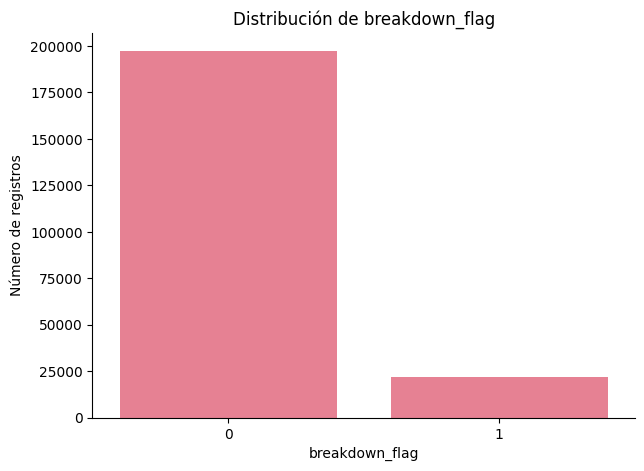

In [ ]:
# =====================================================
# 6. ANÁLISIS DE LA VARIABLE breakdown_flag
# =====================================================

print("=" * 70)
print("DISTRIBUCIÓN DE FALLAS ACTUALES")
print("=" * 70)

failure_counts = df_clean["breakdown_flag"].value_counts().sort_index()
failure_percent = df_clean["breakdown_flag"].value_counts(normalize=True).sort_index() * 100

failure_summary = pd.DataFrame({
    "Registros": failure_counts,
    "Porcentaje (%)": failure_percent.round(2)
})

display(failure_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="breakdown_flag")
plt.title("Distribución de breakdown_flag")
plt.xlabel("breakdown_flag")
plt.ylabel("Número de registros")
plt.show()

## Paso 7 — Verificación de fuga de información con `wo_type`

In [ ]:
# =====================================================
# 7. REVISIÓN DE POSIBLE FUGA DE INFORMACIÓN
# =====================================================

print("=" * 70)
print("RELACIÓN ENTRE wo_type Y breakdown_flag")
print("=" * 70)

display(pd.crosstab(df_clean["wo_type"], df_clean["breakdown_flag"], dropna=False))

print("""
Conclusión:
La columna wo_type no debe usarse como variable predictora porque puede revelar directamente
si una orden de trabajo corresponde a una avería. Incluirla produciría fuga de información.
""")

RELACIÓN ENTRE wo_type Y breakdown_flag


breakdown_flag,0,1
wo_type,,
BD,0,21636
PM,21157,0
NaN,176207,0



Conclusión:
La columna wo_type no debe usarse como variable predictora porque puede revelar directamente
si una orden de trabajo corresponde a una avería. Incluirla produciría fuga de información.



## Paso 8 — Construcción de la variable objetivo predictiva

✅ Variable objetivo predictiva creada: failure_next_3d


,Registros,Porcentaje (%)
failure_next_3d,,
0,161032,73.53
1,57968,26.47


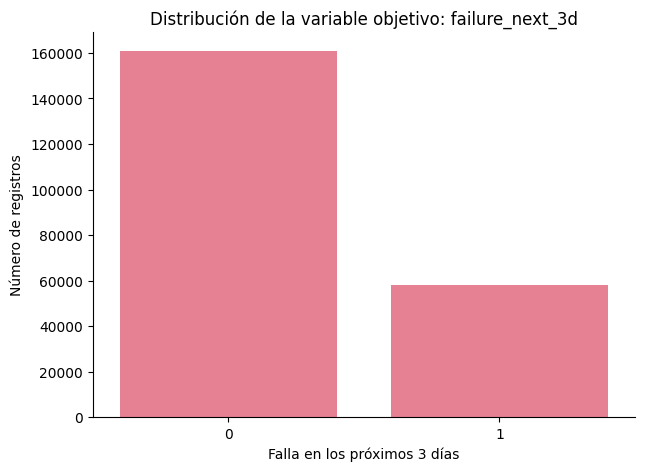

In [ ]:
# =====================================================
# 8. CONSTRUCCIÓN DE VARIABLE OBJETIVO PREDICTIVA
# =====================================================

HORIZON_DAYS = 3

df_model = df_clean.copy()

# Ordenar por activo, componente y fecha
df_model = df_model.sort_values(["asset_tag", "part_no", "transaction_date"]).reset_index(drop=True)

# Crear variable objetivo: falla en los próximos 3 días
future_failure_cols = []

for i in range(1, HORIZON_DAYS + 1):
    col_name = f"breakdown_next_{i}d"
    df_model[col_name] = (
        df_model
        .groupby(["asset_tag", "part_no"])["breakdown_flag"]
        .shift(-i)
    )
    future_failure_cols.append(col_name)

df_model["failure_next_3d"] = df_model[future_failure_cols].max(axis=1).fillna(0).astype(int)

# Eliminar columnas auxiliares
df_model = df_model.drop(columns=future_failure_cols)

print("✅ Variable objetivo predictiva creada: failure_next_3d")

target_summary = df_model["failure_next_3d"].value_counts().sort_index()
target_percent = df_model["failure_next_3d"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Registros": target_summary,
    "Porcentaje (%)": target_percent.round(2)
}))

plt.figure(figsize=(7, 5))
sns.countplot(data=df_model, x="failure_next_3d")
plt.title("Distribución de la variable objetivo: failure_next_3d")
plt.xlabel("Falla en los próximos 3 días")
plt.ylabel("Número de registros")
plt.show()

## Paso 9 — Filtrar registros de falla actual
Para un sistema realmente predictivo, conviene entrenar con registros donde la máquina todavía no está en avería actual. Es decir, queremos anticiparnos a que suceda la averia, obviamente.

In [ ]:
# =====================================================
# 9. FILTRADO PARA ENFOQUE PREDICTIVO
# =====================================================

df_model_predictive = df_model[df_model["breakdown_flag"] == 0].copy()

print("Registros antes del filtrado:", len(df_model))
print("Registros después de eliminar fallas actuales:", len(df_model_predictive))

print("\nDistribución de la variable objetivo después del filtrado:")
display(
    df_model_predictive["failure_next_3d"]
    .value_counts(normalize=False)
    .rename("Registros")
    .to_frame()
)

display(
    (df_model_predictive["failure_next_3d"]
     .value_counts(normalize=True) * 100)
    .round(2)
    .rename("Porcentaje (%)")
    .to_frame()
)

Registros antes del filtrado: 219000
Registros después de eliminar fallas actuales: 197364

Distribución de la variable objetivo después del filtrado:


,Registros
failure_next_3d,
0,145224
1,52140


,Porcentaje (%)
failure_next_3d,
0,73.58
1,26.42


## Paso 10 — Verificación de frecuencia temporal
Lo ideal ahora sería demostrar que el dataset tiene una estructura diaria por activo y componente. Esto justifica técnicamente haber creado failure_next_3d usando desplazamientos hacia adelante. (por seguridad)

In [ ]:
# =====================================================
# 10. VERIFICACIÓN DE ESTRUCTURA TEMPORAL DEL DATASET
# =====================================================

print("=" * 70)
print("VERIFICACIÓN DE FRECUENCIA TEMPORAL")
print("=" * 70)

# Número de combinaciones activo-componente
n_groups = df_model.groupby(["asset_tag", "part_no"]).ngroups
print(f"Número de combinaciones asset_tag + part_no: {n_groups}")

# Registros por combinación activo-componente
group_sizes = (
    df_model
    .groupby(["asset_tag", "part_no"])
    .size()
    .describe()
)

print("\nResumen de registros por activo-componente:")
display(group_sizes)

# Verificar duplicados por activo-componente-fecha
duplicates_apd = df_model.duplicated(["asset_tag", "part_no", "transaction_date"]).sum()
print(f"\nDuplicados por asset_tag + part_no + transaction_date: {duplicates_apd}")

# Verificar diferencias entre fechas consecutivas
date_gaps = (
    df_model
    .sort_values(["asset_tag", "part_no", "transaction_date"])
    .groupby(["asset_tag", "part_no"])["transaction_date"]
    .diff()
    .dt.days
)

print("\nFrecuencia de diferencias entre fechas consecutivas:")
display(date_gaps.value_counts().head(10))

print("""
Conclusión:
Si la diferencia predominante entre registros consecutivos es de 1 día,
la construcción de failure_next_3d representa una ventana predictiva de los próximos 3 días.
""")

VERIFICACIÓN DE FRECUENCIA TEMPORAL
Número de combinaciones asset_tag + part_no: 200

Resumen de registros por activo-componente:


,0
count,200.0
mean,1095.0
std,0.0
min,1095.0
25%,1095.0
50%,1095.0
75%,1095.0
max,1095.0



Duplicados por asset_tag + part_no + transaction_date: 0

Frecuencia de diferencias entre fechas consecutivas:


,count
transaction_date,
1.0,218800



Conclusión:
Si la diferencia predominante entre registros consecutivos es de 1 día,
la construcción de failure_next_3d representa una ventana predictiva de los próximos 3 días.



## Paso 11 — Análisis general del dataset predictivo
Ya teniendo identificado lo anterior, vamos a trabajar con `df_model_predictive`

In [ ]:
# =====================================================
# 11. ANÁLISIS GENERAL DEL DATASET PREDICTIVO
# =====================================================

print("=" * 70)
print("DATASET FINAL PARA MODELADO PREDICTIVO")
print("=" * 70)

print(f"Filas: {df_model_predictive.shape[0]:,}")
print(f"Columnas: {df_model_predictive.shape[1]}")

print("\nRango de fechas:")
print(f"Desde: {df_model_predictive['transaction_date'].min()}")
print(f"Hasta: {df_model_predictive['transaction_date'].max()}")

print("\nNúmero de activos:")
print(df_model_predictive["asset_tag"].nunique())

print("\nNúmero de componentes:")
print(df_model_predictive["part_no"].nunique())

print("\nNúmero de tipos de máquina:")
print(df_model_predictive["machine_type"].nunique())

print("\nNúmero de plantas:")
print(df_model_predictive["plant_code"].nunique())

display(df_model_predictive.head())

DATASET FINAL PARA MODELADO PREDICTIVO
Filas: 197,364
Columnas: 23

Rango de fechas:
Desde: 2022-01-03 00:00:00
Hasta: 2025-01-01 00:00:00

Número de activos:
10

Número de componentes:
20

Número de tipos de máquina:
5

Número de plantas:
3


,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,temp_motor_degC,vibration_h_mms,vibration_v_mms,oil_pressure_bar,load_pct,shaft_rpm,power_consumption_kw,breakdown_flag,wo_type,failure_next_3d
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,63.5,4.944,3.886,3.71,85.9,1794,16.09,0,NaN,0
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,64.8,4.614,3.530,3.67,82.0,1790,15.53,0,NaN,0
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,66.7,4.360,2.976,3.74,83.0,1827,16.20,0,NaN,0
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,68.1,4.522,3.315,3.90,82.9,1811,16.47,0,NaN,0
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,66.3,4.340,3.434,3.71,80.1,1810,15.08,0,NaN,0


## Paso 12 — Diccionario de variables del dataset
Esto es netamente para documentar el documento del proyecto, tambien para facilitar su comprensión. (es mi humilde opinión)


In [ ]:
# =====================================================
# 12. DICCIONARIO DE VARIABLES
# =====================================================

data_dictionary = pd.DataFrame({
    "Variable": [
        "transaction_date",
        "asset_tag",
        "machine_type",
        "plant_code",
        "part_no",
        "part_description",
        "part_family",
        "criticality",
        "uom",
        "unit_cost_inr",
        "qty_issued",
        "issue_value_inr",
        "temp_bearing_degC",
        "temp_motor_degC",
        "vibration_h_mms",
        "vibration_v_mms",
        "oil_pressure_bar",
        "load_pct",
        "shaft_rpm",
        "power_consumption_kw",
        "breakdown_flag",
        "wo_type",
        "failure_next_3d"
    ],
    "Descripción": [
        "Fecha del registro operacional o transaccional",
        "Identificador del activo o máquina",
        "Tipo de máquina industrial",
        "Código de la planta",
        "Código del componente o repuesto",
        "Descripción textual del componente",
        "Familia técnica del componente",
        "Nivel de criticidad del componente o activo",
        "Unidad de medida del componente",
        "Costo unitario del componente",
        "Cantidad emitida o utilizada en la orden",
        "Valor económico emitido",
        "Temperatura del rodamiento en grados Celsius",
        "Temperatura del motor en grados Celsius",
        "Vibración horizontal en mm/s",
        "Vibración vertical en mm/s",
        "Presión de aceite en bar",
        "Porcentaje de carga operativa",
        "Velocidad de rotación del eje en rpm",
        "Consumo de potencia en kW",
        "Indicador de avería actual",
        "Tipo de orden de trabajo",
        "Variable objetivo: avería en los próximos 3 días"
    ],
    "Uso en el modelo": [
        "Base para variables temporales",
        "Predictora categórica",
        "Predictora categórica",
        "Predictora categórica",
        "Predictora categórica",
        "No usada directamente",
        "Predictora categórica",
        "Predictora categórica",
        "No usada directamente",
        "Predictora numérica",
        "No usada en modelo principal",
        "No usada en modelo principal",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "Predictora numérica",
        "No usada como predictora",
        "No usada por fuga de información",
        "Variable objetivo"
    ]
})

display(data_dictionary)

,Variable,Descripción,Uso en el modelo
0,transaction_date,Fecha del registro operacional o transaccional,Base para variables temporales
1,asset_tag,Identificador del activo o máquina,Predictora categórica
2,machine_type,Tipo de máquina industrial,Predictora categórica
3,plant_code,Código de la planta,Predictora categórica
4,part_no,Código del componente o repuesto,Predictora categórica
5,part_description,Descripción textual del componente,No usada directamente
6,part_family,Familia técnica del componente,Predictora categórica
7,criticality,Nivel de criticidad del componente o activo,Predictora categórica
8,uom,Unidad de medida del componente,No usada directamente
9,unit_cost_inr,Costo unitario del componente,Predictora numérica


## Paso 13 — Análisis de la variable objetivo predictiva

,Registros,Porcentaje (%)
failure_next_3d,,
0,145224,73.58
1,52140,26.42


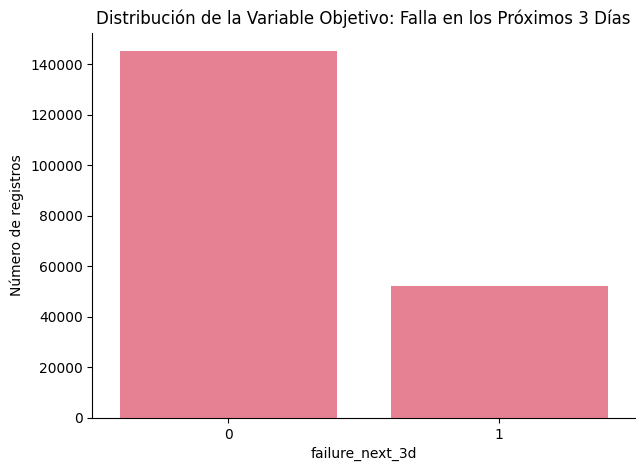

In [ ]:
# =====================================================
# 13. ANÁLISIS DE LA VARIABLE OBJETIVO PREDICTIVA
# =====================================================

target_col = "failure_next_3d"

target_counts = df_model_predictive[target_col].value_counts().sort_index()
target_percent = df_model_predictive[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Registros": target_counts,
    "Porcentaje (%)": target_percent.round(2)
})

display(target_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=df_model_predictive, x=target_col)
plt.title("Distribución de la Variable Objetivo: Falla en los Próximos 3 Días")
plt.xlabel("failure_next_3d")
plt.ylabel("Número de registros")
plt.show()

## Paso 14 — Fallas futuras por tipo de máquina
Esta gráfica ayuda a traducir el modelo a negocio: qué máquinas presentan más riesgo.

,registros,fallas_futuras,tasa_falla_futura,tasa_falla_futura_%
machine_type,,,,
Hydraulic Press,38842,11638,0.299624,29.96
Screw Compressor,39140,11111,0.283878,28.39
EOT Crane,39502,10363,0.262341,26.23
CNC Lathe,39818,9732,0.244412,24.44
Belt Conveyor,40062,9296,0.232040,23.20


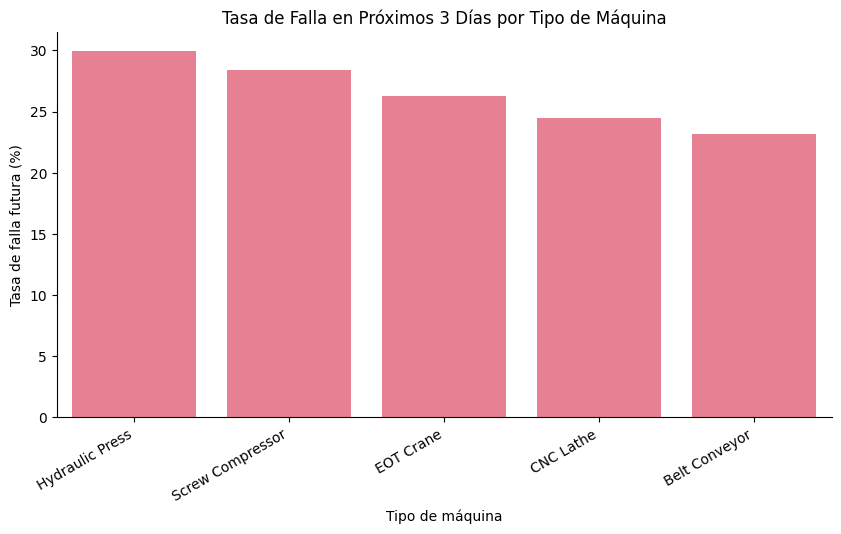

In [ ]:
# =====================================================
# 14. TASA DE FALLA FUTURA POR TIPO DE MÁQUINA
# =====================================================

failure_by_machine = (
    df_model_predictive
    .groupby("machine_type")[target_col]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "registros",
        "sum": "fallas_futuras",
        "mean": "tasa_falla_futura"
    })
    .sort_values("tasa_falla_futura", ascending=False)
)

failure_by_machine["tasa_falla_futura_%"] = (
    failure_by_machine["tasa_falla_futura"] * 100
).round(2)

display(failure_by_machine)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=failure_by_machine.reset_index(),
    x="machine_type",
    y="tasa_falla_futura_%"
)
plt.title("Tasa de Falla en Próximos 3 Días por Tipo de Máquina")
plt.xlabel("Tipo de máquina")
plt.ylabel("Tasa de falla futura (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

## Paso 15 — Fallas futuras por familia de componente

,registros,fallas_futuras,tasa_falla_futura,tasa_falla_futura_%
part_family,,,,
Bearing,28629,9512,0.332251,33.23
Sensor,19446,5762,0.296308,29.63
Electrical,19483,5748,0.295026,29.50
Filter,19764,5282,0.267254,26.73
Drive Belt,19766,5231,0.264646,26.46
Seal & Gasket,29732,7562,0.254339,25.43
Coupling,19913,4912,0.246673,24.67
Fastener,20274,4138,0.204104,20.41
Lubrication,20357,3993,0.196149,19.61


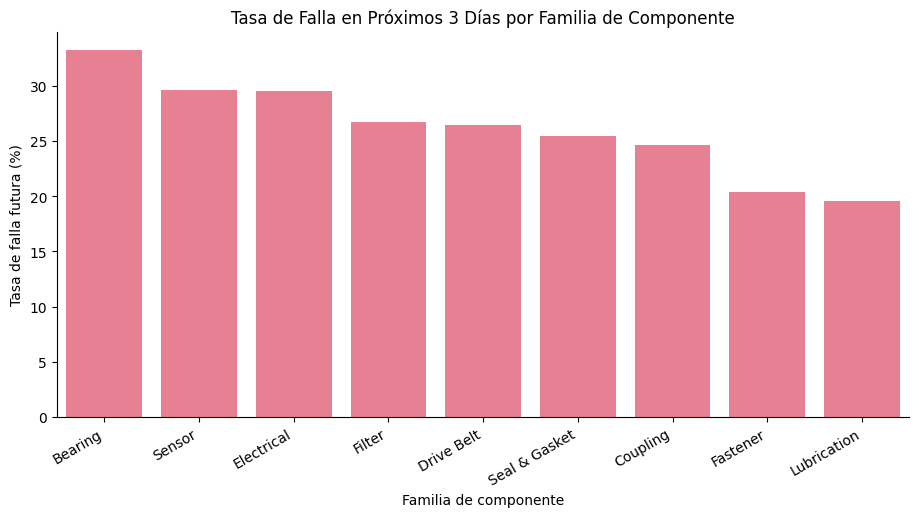

In [ ]:
# =====================================================
# 15. TASA DE FALLA FUTURA POR FAMILIA DE COMPONENTE
# =====================================================

failure_by_part_family = (
    df_model_predictive
    .groupby("part_family")[target_col]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "registros",
        "sum": "fallas_futuras",
        "mean": "tasa_falla_futura"
    })
    .sort_values("tasa_falla_futura", ascending=False)
)

failure_by_part_family["tasa_falla_futura_%"] = (
    failure_by_part_family["tasa_falla_futura"] * 100
).round(2)

display(failure_by_part_family)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=failure_by_part_family.reset_index(),
    x="part_family",
    y="tasa_falla_futura_%"
)
plt.title("Tasa de Falla en Próximos 3 Días por Familia de Componente")
plt.xlabel("Familia de componente")
plt.ylabel("Tasa de falla futura (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

## Paso 16 — Fallas futuras por criticidad

,registros,fallas_futuras,tasa_falla_futura,tasa_falla_futura_%
criticality,,,,
A,57296,19051,0.332501,33.25
B,89175,23116,0.259221,25.92
C,50893,9973,0.195960,19.60


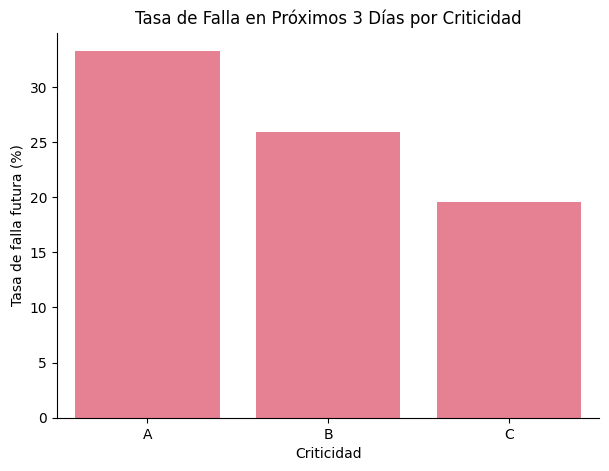

In [ ]:
# =====================================================
# 16. TASA DE FALLA FUTURA POR CRITICIDAD
# =====================================================

failure_by_criticality = (
    df_model_predictive
    .groupby("criticality")[target_col]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "registros",
        "sum": "fallas_futuras",
        "mean": "tasa_falla_futura"
    })
    .sort_values("tasa_falla_futura", ascending=False)
)

failure_by_criticality["tasa_falla_futura_%"] = (
    failure_by_criticality["tasa_falla_futura"] * 100
).round(2)

display(failure_by_criticality)

plt.figure(figsize=(7, 5))
sns.barplot(
    data=failure_by_criticality.reset_index(),
    x="criticality",
    y="tasa_falla_futura_%"
)
plt.title("Tasa de Falla en Próximos 3 Días por Criticidad")
plt.xlabel("Criticidad")
plt.ylabel("Tasa de falla futura (%)")
plt.show()

## Paso 17 — Comparación de variables operativas según falla futura

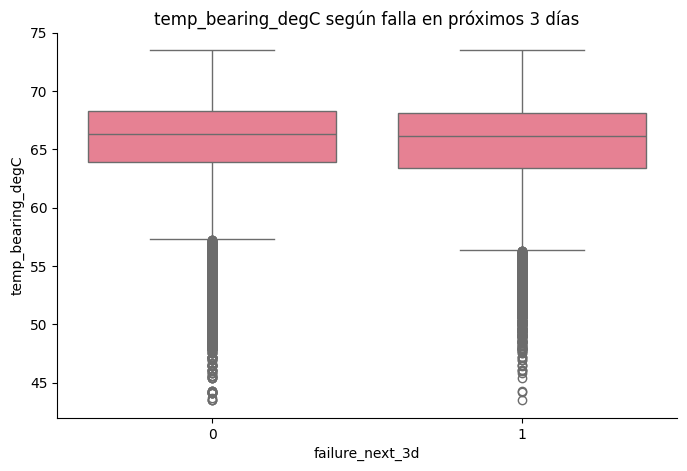

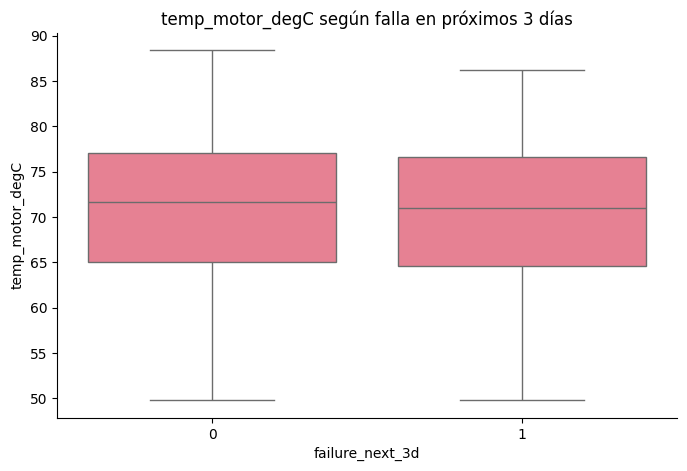

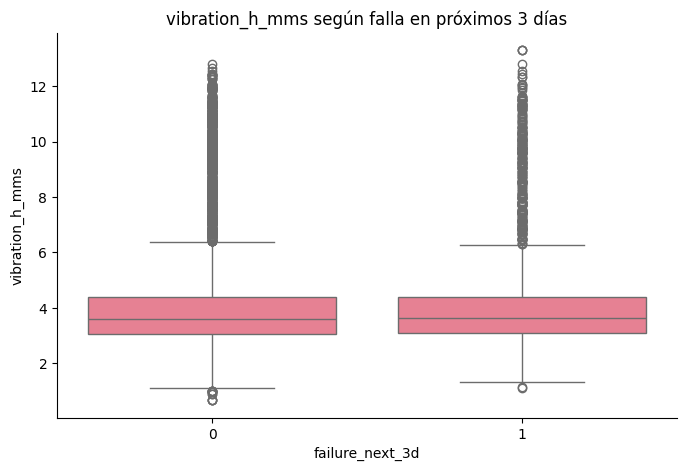

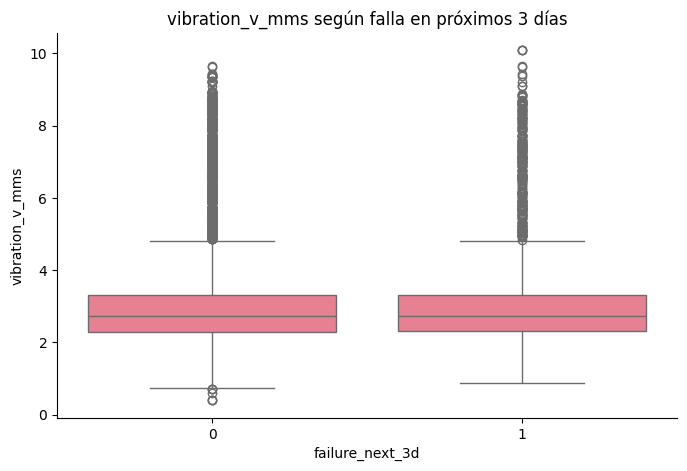

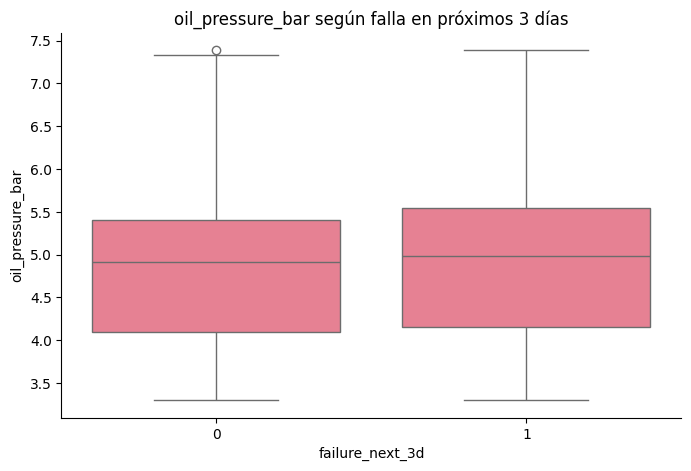

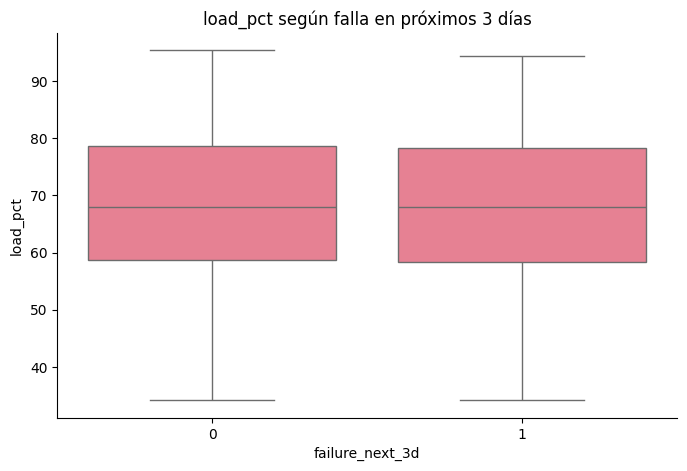

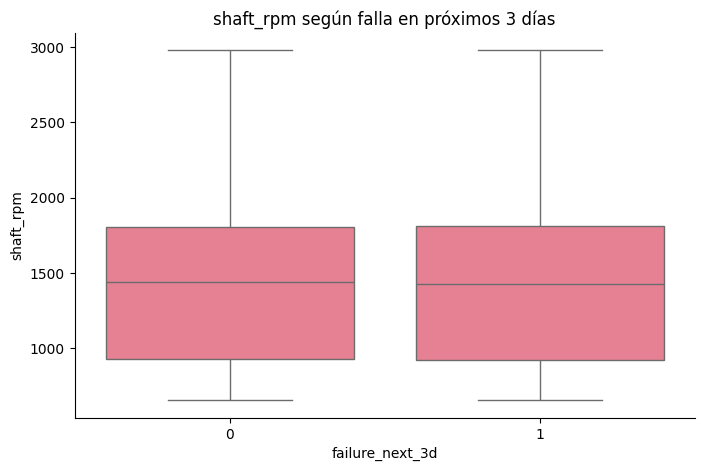

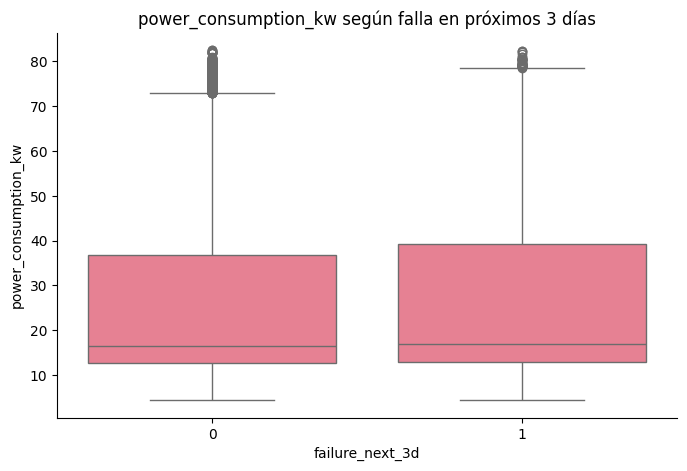

In [ ]:
# =====================================================
# 17. VARIABLES OPERATIVAS SEGÚN FALLA FUTURA
# =====================================================

sensor_cols = [
    "temp_bearing_degC",
    "temp_motor_degC",
    "vibration_h_mms",
    "vibration_v_mms",
    "oil_pressure_bar",
    "load_pct",
    "shaft_rpm",
    "power_consumption_kw"
]

# Usar muestra para que los gráficos sean más rápidos
eda_sample = df_model_predictive.sample(
    n=min(30000, len(df_model_predictive)),
    random_state=RANDOM_SEED
)

for col in sensor_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=eda_sample, x=target_col, y=col)
    plt.title(f"{col} según falla en próximos 3 días")
    plt.xlabel("failure_next_3d")
    plt.ylabel(col)
    plt.show()

## Paso 18 — Correlación entre variables numéricas

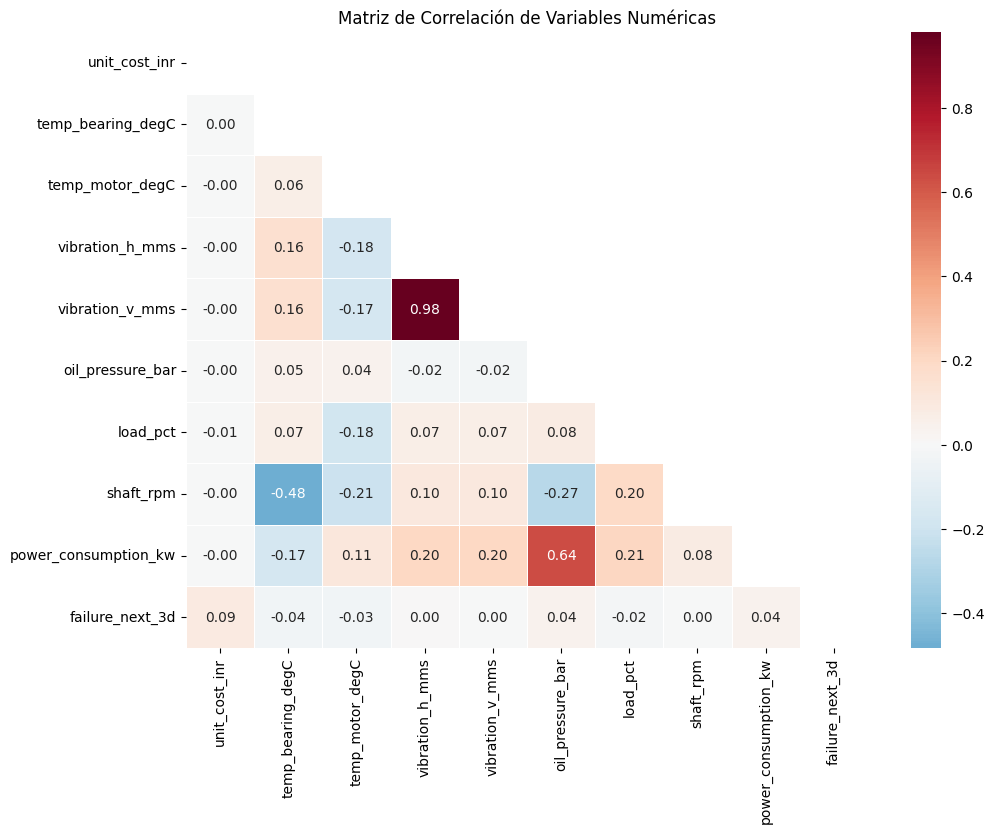

Correlación con la variable objetivo:


,correlación
unit_cost_inr,0.092906
oil_pressure_bar,0.044675
power_consumption_kw,0.038284
temp_bearing_degC,-0.036514
temp_motor_degC,-0.031338
load_pct,-0.018384
vibration_h_mms,0.003726
vibration_v_mms,0.002727
shaft_rpm,0.000858


In [ ]:
# =====================================================
# 18. MATRIZ DE CORRELACIÓN
# =====================================================

numeric_cols_corr = [
    "unit_cost_inr",
    "temp_bearing_degC",
    "temp_motor_degC",
    "vibration_h_mms",
    "vibration_v_mms",
    "oil_pressure_bar",
    "load_pct",
    "shaft_rpm",
    "power_consumption_kw",
    target_col
]

corr_matrix = df_model_predictive[numeric_cols_corr].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

print("Correlación con la variable objetivo:")
display(
    corr_matrix[target_col]
    .drop(target_col)
    .sort_values(key=abs, ascending=False)
    .to_frame("correlación")
)

## Paso 19 — Feature engineering temporal y operacional
Diría que esta es una de las partes más importantes, ya que se van a crear:


*   variables de calendario
*   diferencias de temperatura
*   magnitud combinada de vibración
*   potencia relativa a la carga
*   variables rolling de 3 y 7 días
*   cambios respecto al día anterior


In [ ]:
# =====================================================
# 19. FEATURE ENGINEERING
# =====================================================

df_features = df_model_predictive.copy()

# -----------------------------------------------------
# Variables temporales
# -----------------------------------------------------
df_features["year"] = df_features["transaction_date"].dt.year
df_features["month"] = df_features["transaction_date"].dt.month
df_features["dayofweek"] = df_features["transaction_date"].dt.dayofweek
df_features["dayofyear"] = df_features["transaction_date"].dt.dayofyear
df_features["is_weekend"] = (df_features["dayofweek"] >= 5).astype(int)

# -----------------------------------------------------
# Variables operacionales derivadas
# -----------------------------------------------------
df_features["temp_diff_motor_bearing"] = (
    df_features["temp_motor_degC"] - df_features["temp_bearing_degC"]
)

df_features["temp_mean"] = (
    df_features["temp_motor_degC"] + df_features["temp_bearing_degC"]
) / 2

df_features["vibration_combined"] = np.sqrt(
    df_features["vibration_h_mms"]**2 + df_features["vibration_v_mms"]**2
)

df_features["vibration_ratio_h_v"] = (
    df_features["vibration_h_mms"] / (df_features["vibration_v_mms"] + 1e-6)
)

df_features["power_per_load"] = (
    df_features["power_consumption_kw"] / (df_features["load_pct"] + 1e-6)
)

df_features["torque_proxy"] = (
    df_features["power_consumption_kw"] / (df_features["shaft_rpm"] + 1e-6)
)

# -----------------------------------------------------
# Variables rolling por activo-componente
# -----------------------------------------------------
rolling_base_cols = [
    "temp_bearing_degC",
    "temp_motor_degC",
    "vibration_h_mms",
    "vibration_v_mms",
    "oil_pressure_bar",
    "load_pct",
    "shaft_rpm",
    "power_consumption_kw",
    "vibration_combined"
]

df_features = df_features.sort_values(
    ["asset_tag", "part_no", "transaction_date"]
).reset_index(drop=True)

for col in rolling_base_cols:
    # Cambio frente al día anterior
    df_features[f"{col}_diff_1d"] = (
        df_features
        .groupby(["asset_tag", "part_no"])[col]
        .diff()
    )

    # Media móvil 3 días
    df_features[f"{col}_roll_mean_3d"] = (
        df_features
        .groupby(["asset_tag", "part_no"])[col]
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # Desviación móvil 3 días
    df_features[f"{col}_roll_std_3d"] = (
        df_features
        .groupby(["asset_tag", "part_no"])[col]
        .transform(lambda x: x.rolling(window=3, min_periods=2).std())
    )

    # Media móvil 7 días
    df_features[f"{col}_roll_mean_7d"] = (
        df_features
        .groupby(["asset_tag", "part_no"])[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    )

    # Desviación móvil 7 días
    df_features[f"{col}_roll_std_7d"] = (
        df_features
        .groupby(["asset_tag", "part_no"])[col]
        .transform(lambda x: x.rolling(window=7, min_periods=2).std())
    )

# Rellenar NaN generados por diff y rolling std inicial
numeric_feature_cols = df_features.select_dtypes(include=[np.number]).columns
df_features[numeric_feature_cols] = df_features[numeric_feature_cols].fillna(0)

print("✅ Feature engineering completado")
print(f"Dimensiones antes: {df_model_predictive.shape}")
print(f"Dimensiones después: {df_features.shape}")

display(df_features.head())

✅ Feature engineering completado
Dimensiones antes: (197364, 23)
Dimensiones después: (197364, 79)


,transaction_date,asset_tag,machine_type,plant_code,part_no,part_description,part_family,criticality,uom,unit_cost_inr,...,power_consumption_kw_diff_1d,power_consumption_kw_roll_mean_3d,power_consumption_kw_roll_std_3d,power_consumption_kw_roll_mean_7d,power_consumption_kw_roll_std_7d,vibration_combined_diff_1d,vibration_combined_roll_mean_3d,vibration_combined_roll_std_3d,vibration_combined_roll_mean_7d,vibration_combined_roll_std_7d
0,2022-01-03,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,0.00,16.090000,0.000000,16.0900,0.000000,0.000000,6.288413,0.000000,6.288413,0.000000
1,2022-01-04,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,-0.56,15.810000,0.395980,15.8100,0.395980,-0.478946,6.048939,0.338666,6.048939,0.338666
2,2022-01-05,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,0.67,15.940000,0.359305,15.9400,0.359305,-0.530624,5.792240,0.505005,5.792240,0.505005
3,2022-01-06,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,0.27,16.066667,0.483977,16.0725,0.395337,0.328092,5.565081,0.267776,5.745914,0.422617
4,2022-01-07,AST-1041,CNC Lathe,PUN-01,MRO-10045,Deep Groove Ball Bearing 6205-2RS,Bearing,A,EA,850,...,-1.39,15.916667,0.737044,15.8740,0.560562,-0.072681,5.473343,0.172318,5.703582,0.378039


## Paso 20 — Revisión de columnas finales

In [ ]:
# =====================================================
# 20. REVISIÓN DE COLUMNAS FINALES
# =====================================================

print("Columnas disponibles después del feature engineering:")
for col in df_features.columns:
    print("-", col)

print(f"\nTotal de columnas: {df_features.shape[1]}")

Columnas disponibles después del feature engineering:
- transaction_date
- asset_tag
- machine_type
- plant_code
- part_no
- part_description
- part_family
- criticality
- uom
- unit_cost_inr
- qty_issued
- issue_value_inr
- temp_bearing_degC
- temp_motor_degC
- vibration_h_mms
- vibration_v_mms
- oil_pressure_bar
- load_pct
- shaft_rpm
- power_consumption_kw
- breakdown_flag
- wo_type
- failure_next_3d
- year
- month
- dayofweek
- dayofyear
- is_weekend
- temp_diff_motor_bearing
- temp_mean
- vibration_combined
- vibration_ratio_h_v
- power_per_load
- torque_proxy
- temp_bearing_degC_diff_1d
- temp_bearing_degC_roll_mean_3d
- temp_bearing_degC_roll_std_3d
- temp_bearing_degC_roll_mean_7d
- temp_bearing_degC_roll_std_7d
- temp_motor_degC_diff_1d
- temp_motor_degC_roll_mean_3d
- temp_motor_degC_roll_std_3d
- temp_motor_degC_roll_mean_7d
- temp_motor_degC_roll_std_7d
- vibration_h_mms_diff_1d
- vibration_h_mms_roll_mean_3d
- vibration_h_mms_roll_std_3d
- vibration_h_mms_roll_mean_7d
- vi

## Paso 21 — Definición de variables predictoras y variable objetivo
Aquí directamente lo que vamos a hacer es excluir las columnas problematicas.

In [ ]:
# =====================================================
# 21. DEFINICIÓN DE X E y
# =====================================================

TARGET_COLUMN = "failure_next_3d"

# Columnas que NO deben entrar al modelo
leakage_or_unused_cols = [
    "failure_next_3d",      # variable objetivo
    "breakdown_flag",      # falla actual
    "wo_type",             # fuga de información
    "transaction_date",    # se usa para split temporal, no directamente
    "part_description",    # texto descriptivo redundante
    "uom",                 # unidad de medida, poco útil para el modelo
    "qty_issued",          # posible información posterior a mantenimiento
    "issue_value_inr"      # posible información posterior a mantenimiento
]

X = df_features.drop(columns=leakage_or_unused_cols, errors="ignore")
y = df_features[TARGET_COLUMN]

print("✅ X e y definidos")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nDistribución de y:")
display(y.value_counts(normalize=True).mul(100).round(2).to_frame("Porcentaje (%)"))

print("\nColumnas predictoras:")
for col in X.columns:
    print("-", col)

✅ X e y definidos
X shape: (197364, 71)
y shape: (197364,)

Distribución de y:


,Porcentaje (%)
failure_next_3d,
0,73.58
1,26.42



Columnas predictoras:
- asset_tag
- machine_type
- plant_code
- part_no
- part_family
- criticality
- unit_cost_inr
- temp_bearing_degC
- temp_motor_degC
- vibration_h_mms
- vibration_v_mms
- oil_pressure_bar
- load_pct
- shaft_rpm
- power_consumption_kw
- year
- month
- dayofweek
- dayofyear
- is_weekend
- temp_diff_motor_bearing
- temp_mean
- vibration_combined
- vibration_ratio_h_v
- power_per_load
- torque_proxy
- temp_bearing_degC_diff_1d
- temp_bearing_degC_roll_mean_3d
- temp_bearing_degC_roll_std_3d
- temp_bearing_degC_roll_mean_7d
- temp_bearing_degC_roll_std_7d
- temp_motor_degC_diff_1d
- temp_motor_degC_roll_mean_3d
- temp_motor_degC_roll_std_3d
- temp_motor_degC_roll_mean_7d
- temp_motor_degC_roll_std_7d
- vibration_h_mms_diff_1d
- vibration_h_mms_roll_mean_3d
- vibration_h_mms_roll_std_3d
- vibration_h_mms_roll_mean_7d
- vibration_h_mms_roll_std_7d
- vibration_v_mms_diff_1d
- vibration_v_mms_roll_mean_3d
- vibration_v_mms_roll_std_3d
- vibration_v_mms_roll_mean_7d
- vibra

## Paso 22 — Separación de variables numéricas y categóricas

In [ ]:
# =====================================================
# 22. IDENTIFICACIÓN DE VARIABLES NUMÉRICAS Y CATEGÓRICAS
# =====================================================

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variables categóricas ({len(categorical_features)}):")
print(categorical_features)

print(f"\nVariables numéricas ({len(numeric_features)}):")
print(numeric_features)

Variables categóricas (6):
['asset_tag', 'machine_type', 'plant_code', 'part_no', 'part_family', 'criticality']

Variables numéricas (65):
['unit_cost_inr', 'temp_bearing_degC', 'temp_motor_degC', 'vibration_h_mms', 'vibration_v_mms', 'oil_pressure_bar', 'load_pct', 'shaft_rpm', 'power_consumption_kw', 'year', 'month', 'dayofweek', 'dayofyear', 'is_weekend', 'temp_diff_motor_bearing', 'temp_mean', 'vibration_combined', 'vibration_ratio_h_v', 'power_per_load', 'torque_proxy', 'temp_bearing_degC_diff_1d', 'temp_bearing_degC_roll_mean_3d', 'temp_bearing_degC_roll_std_3d', 'temp_bearing_degC_roll_mean_7d', 'temp_bearing_degC_roll_std_7d', 'temp_motor_degC_diff_1d', 'temp_motor_degC_roll_mean_3d', 'temp_motor_degC_roll_std_3d', 'temp_motor_degC_roll_mean_7d', 'temp_motor_degC_roll_std_7d', 'vibration_h_mms_diff_1d', 'vibration_h_mms_roll_mean_3d', 'vibration_h_mms_roll_std_3d', 'vibration_h_mms_roll_mean_7d', 'vibration_h_mms_roll_std_7d', 'vibration_v_mms_diff_1d', 'vibration_v_mms_roll_me

## Paso 23 — Eliminar registros censurados del final de cada serie

In [ ]:
# =====================================================
# 23. ELIMINACIÓN DE REGISTROS CENSURADOS
# =====================================================

print("=" * 70)
print("ELIMINACIÓN DE REGISTROS CENSURADOS")
print("=" * 70)

HORIZON_DAYS = 3

df_features = df_features.sort_values(
    ["asset_tag", "part_no", "transaction_date"]
).reset_index(drop=True)

# Posición inversa dentro de cada grupo activo-componente
df_features["reverse_position"] = (
    df_features
    .groupby(["asset_tag", "part_no"])
    .cumcount(ascending=False)
)

# Eliminar los últimos HORIZON_DAYS registros de cada activo-componente
df_features_model = df_features[df_features["reverse_position"] >= HORIZON_DAYS].copy()

# Eliminar columna auxiliar
df_features_model = df_features_model.drop(columns=["reverse_position"])

print(f"Registros antes: {len(df_features):,}")
print(f"Registros después: {len(df_features_model):,}")
print(f"Registros eliminados: {len(df_features) - len(df_features_model):,}")

print("\nDistribución de la variable objetivo después de eliminar registros censurados:")
display(
    df_features_model["failure_next_3d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Porcentaje (%)")
)

ELIMINACIÓN DE REGISTROS CENSURADOS
Registros antes: 197,364
Registros después: 196,764
Registros eliminados: 600

Distribución de la variable objetivo después de eliminar registros censurados:


,Porcentaje (%)
failure_next_3d,
0,73.59
1,26.41


## Paso 24 — Redefinir X e y después del ajuste

In [ ]:
# =====================================================
# 24. REDEFINICIÓN DE X E y PARA MODELADO FINAL
# =====================================================

TARGET_COLUMN = "failure_next_3d"

leakage_or_unused_cols = [
    "failure_next_3d",
    "breakdown_flag",
    "wo_type",
    "transaction_date",
    "part_description",
    "uom",
    "qty_issued",
    "issue_value_inr"
]

X = df_features_model.drop(columns=leakage_or_unused_cols, errors="ignore")
y = df_features_model[TARGET_COLUMN]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("✅ X e y redefinidos correctamente")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(f"\nVariables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")

print("\nVariables categóricas:")
print(categorical_features)

print("\nDistribución final de y:")
display(y.value_counts(normalize=True).mul(100).round(2).to_frame("Porcentaje (%)"))

✅ X e y redefinidos correctamente
X shape: (196764, 71)
y shape: (196764,)

Variables numéricas: 65
Variables categóricas: 6

Variables categóricas:
['asset_tag', 'machine_type', 'plant_code', 'part_no', 'part_family', 'criticality']

Distribución final de y:


,Porcentaje (%)
failure_next_3d,
0,73.59
1,26.41


## Paso 25 — División temporal train / validation / test
Aquí evitamos hacer una división aleatoria. Entrenaremos con datos antiguos, validaremos con datos intermedios y probaremos con datos más recientes.

In [ ]:
# =====================================================
# 25. DIVISIÓN TEMPORAL TRAIN / VALIDATION / TEST
# =====================================================

print("=" * 70)
print("DIVISIÓN TEMPORAL")
print("=" * 70)

# Ordenar por fecha
df_features_model = df_features_model.sort_values("transaction_date").reset_index(drop=True)

# Redefinir X e y para asegurar que tienen el índice correcto después del ordenamiento
TARGET_COLUMN = "failure_next_3d"
leakage_or_unused_cols = [
    "failure_next_3d",
    "breakdown_flag",
    "wo_type",
    "transaction_date",
    "part_description",
    "uom",
    "qty_issued",
    "issue_value_inr"
]
X = df_features_model.drop(columns=leakage_or_unused_cols, errors="ignore")
y = df_features_model[TARGET_COLUMN]

# Cortes temporales por cuantiles
train_cutoff = df_features_model["transaction_date"].quantile(0.70)
val_cutoff = df_features_model["transaction_date"].quantile(0.85)

print(f"Fecha máxima para train: {train_cutoff}")
print(f"Fecha máxima para validation: {val_cutoff}")

train_mask = df_features_model["transaction_date"] <= train_cutoff
val_mask = (
    (df_features_model["transaction_date"] > train_cutoff) &
    (df_features_model["transaction_date"] <= val_cutoff)
)
test_mask = df_features_model["transaction_date"] > val_cutoff

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("\nTamaños de conjuntos:")
print(f"Train:      {X_train.shape[0]:,} registros")
print(f"Validation: {X_val.shape[0]:,} registros")
print(f"Test:       {X_test.shape[0]:,} registros")

print("\nDistribución de clases por conjunto:")
split_summary = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).mul(100).round(2),
    "Validation (%)": y_val.value_counts(normalize=True).mul(100).round(2),
    "Test (%)": y_test.value_counts(normalize=True).mul(100).round(2)
})

display(split_summary)


DIVISIÓN TEMPORAL
Fecha máxima para train: 2024-02-06 00:00:00
Fecha máxima para validation: 2024-07-19 00:00:00

Tamaños de conjuntos:
Train:      137,851 registros
Validation: 29,548 registros
Test:       29,365 registros

Distribución de clases por conjunto:


,Train (%),Validation (%),Test (%)
failure_next_3d,,,
0,73.4,74.04,74.0
1,26.6,25.96,26.0


## Paso 26 — Preprocesamiento con `ColumnTransformer`

In [ ]:
# =====================================================
# 26. PREPROCESAMIENTO
# =====================================================

print("=" * 70)
print("PREPROCESAMIENTO")
print("=" * 70)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="drop"
)

print("✅ Preprocessor definido")
print(f"Variables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")

PREPROCESAMIENTO
✅ Preprocessor definido
Variables numéricas: 65
Variables categóricas: 6


## Paso 27 — Función general de evaluación
Esta función nos permitirá evaluar todos los modelos de forma uniforme.

In [ ]:
# =====================================================
# 27. FUNCIÓN DE EVALUACIÓN DE MODELOS
# =====================================================

def evaluate_model(model_name, model, X_data, y_true, threshold=0.5):
    """
    Evalúa un modelo de clasificación binaria usando métricas relevantes
    para mantenimiento predictivo.
    """

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)[:, 1]
    else:
        y_proba = model.decision_function(X_data)

    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }

    return metrics, y_pred, y_proba

## Paso 28 — Modelo baseline: Logistic Regression

In [ ]:
# =====================================================
# 28. MODELO BASELINE: LOGISTIC REGRESSION
# =====================================================

print("=" * 70)
print("ENTRENAMIENTO MODELO BASELINE: LOGISTIC REGRESSION")
print("=" * 70)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

baseline_model.fit(X_train, y_train)

baseline_metrics_val, baseline_pred_val, baseline_proba_val = evaluate_model(
    "Logistic Regression",
    baseline_model,
    X_val,
    y_val
)

print("✅ Modelo baseline entrenado")
display(pd.DataFrame([baseline_metrics_val]))

ENTRENAMIENTO MODELO BASELINE: LOGISTIC REGRESSION
✅ Modelo baseline entrenado


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.589651,0.343189,0.635593,0.445714,0.640298,0.364057


## Paso 29 — Random Forest

In [ ]:
# =====================================================
# 29. MODELO 2: RANDOM FOREST
# =====================================================

print("=" * 70)
print("ENTRENAMIENTO MODELO: RANDOM FOREST")
print("=" * 70)

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_metrics_val, rf_pred_val, rf_proba_val = evaluate_model(
    "Random Forest",
    rf_model,
    X_val,
    y_val
)

print("✅ Random Forest entrenado")
display(pd.DataFrame([rf_metrics_val]))

ENTRENAMIENTO MODELO: RANDOM FOREST
✅ Random Forest entrenado


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.629213,0.361092,0.556845,0.438096,0.649512,0.37752


## Paso 30 — Gradient Boosting

In [ ]:
# =====================================================
# 30. MODELO 3: GRADIENT BOOSTING
# =====================================================

print("=" * 70)
print("ENTRENAMIENTO MODELO: GRADIENT BOOSTING")
print("=" * 70)

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_SEED
    ))
])

gb_model.fit(X_train, y_train)

gb_metrics_val, gb_pred_val, gb_proba_val = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_val,
    y_val
)

print("✅ Gradient Boosting entrenado")
display(pd.DataFrame([gb_metrics_val]))

ENTRENAMIENTO MODELO: GRADIENT BOOSTING
✅ Gradient Boosting entrenado


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Gradient Boosting,0.741302,0.524715,0.035984,0.06735,0.653981,0.382908


## Paso 31 — XGBoost

In [ ]:
# =====================================================
# 31. MODELO 4: XGBOOST
# =====================================================

print("=" * 70)
print("ENTRENAMIENTO MODELO: XGBOOST")
print("=" * 70)

# Peso para clase positiva
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_metrics_val, xgb_pred_val, xgb_proba_val = evaluate_model(
    "XGBoost",
    xgb_model,
    X_val,
    y_val
)

print("✅ XGBoost entrenado")
display(pd.DataFrame([xgb_metrics_val]))

ENTRENAMIENTO MODELO: XGBOOST
✅ XGBoost entrenado


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.604542,0.350108,0.611343,0.445236,0.651361,0.37911


## Paso 32 — Comparación de modelos en validación

COMPARACIÓN DE MODELOS EN VALIDATION


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.589651,0.343189,0.635593,0.445714,0.640298,0.364057
3,XGBoost,0.604542,0.350108,0.611343,0.445236,0.651361,0.379110
1,Random Forest,0.629213,0.361092,0.556845,0.438096,0.649512,0.377520
2,Gradient Boosting,0.741302,0.524715,0.035984,0.067350,0.653981,0.382908


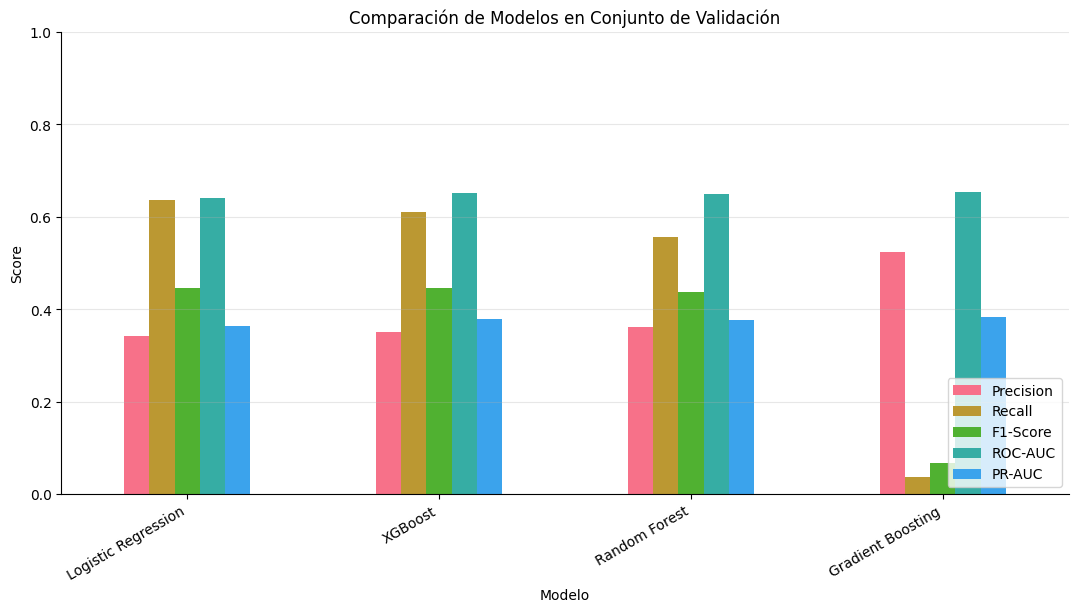

In [ ]:
# =====================================================
# 32. COMPARACIÓN DE MODELOS EN VALIDATION
# =====================================================

validation_results = pd.DataFrame([
    baseline_metrics_val,
    rf_metrics_val,
    gb_metrics_val,
    xgb_metrics_val
])

validation_results = validation_results.sort_values("F1-Score", ascending=False)

print("=" * 70)
print("COMPARACIÓN DE MODELOS EN VALIDATION")
print("=" * 70)

display(validation_results)

# Visualización
metrics_to_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

validation_results_plot = validation_results.set_index("Modelo")[metrics_to_plot]

validation_results_plot.plot(kind="bar", figsize=(13, 6))
plt.title("Comparación de Modelos en Conjunto de Validación")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Paso 33 — Selección automática del mejor modelo

In [ ]:
# =====================================================
# 33. SELECCIÓN DEL MEJOR MODELO
# =====================================================

best_model_name = validation_results.iloc[0]["Modelo"]

model_dict = {
    "Logistic Regression": baseline_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

best_model = model_dict[best_model_name]

print(f"✅ Mejor modelo según F1-Score en validation: {best_model_name}")

✅ Mejor modelo según F1-Score en validation: Logistic Regression


## Paso 35 — Evaluación final en test

EVALUACIÓN FINAL EN TEST


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.575788,0.34186,0.682646,0.455574,0.652083,0.379831



Reporte de clasificación:
                  precision    recall  f1-score   support

No falla próxima       0.83      0.54      0.65     21730
   Falla próxima       0.34      0.68      0.46      7635

        accuracy                           0.58     29365
       macro avg       0.59      0.61      0.55     29365
    weighted avg       0.70      0.58      0.60     29365



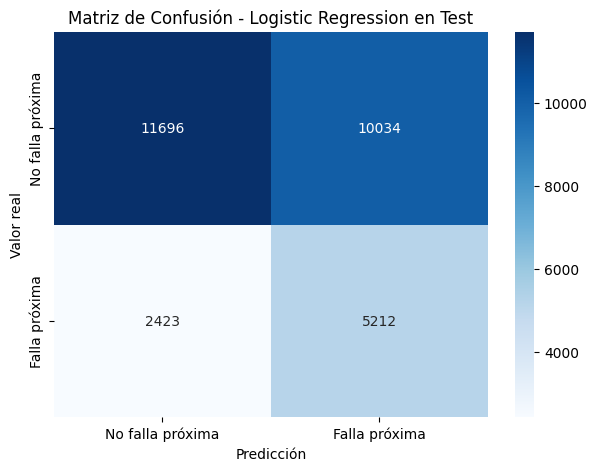

Verdaderos negativos: 11,696
Falsos positivos:    10,034
Falsos negativos:    2,423
Verdaderos positivos:5,212


In [ ]:
# =====================================================
# 34. EVALUACIÓN FINAL EN TEST
# =====================================================

print("=" * 70)
print("EVALUACIÓN FINAL EN TEST")
print("=" * 70)

test_metrics, y_test_pred, y_test_proba = evaluate_model(
    best_model_name,
    best_model,
    X_test,
    y_test
)

display(pd.DataFrame([test_metrics]))

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No falla próxima", "Falla próxima"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No falla próxima", "Falla próxima"],
    yticklabels=["No falla próxima", "Falla próxima"]
)
plt.title(f"Matriz de Confusión - {best_model_name} en Test")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos negativos: {tn:,}")
print(f"Falsos positivos:    {fp:,}")
print(f"Falsos negativos:    {fn:,}")
print(f"Verdaderos positivos:{tp:,}")

## Paso 35 — Curva ROC y Precision-Recall

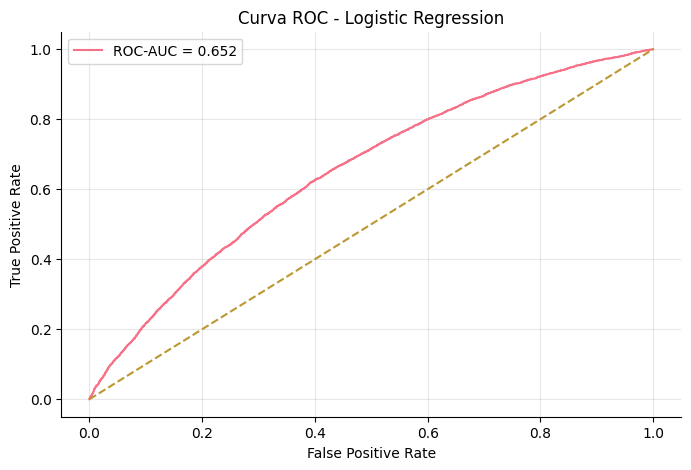

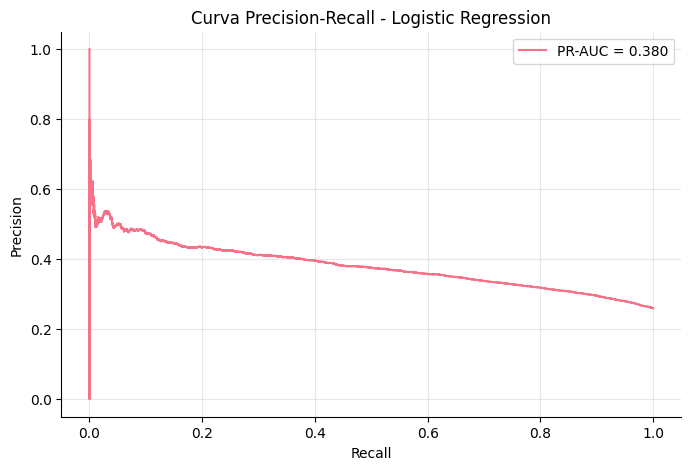

In [ ]:
# =====================================================
# 35. CURVAS ROC Y PRECISION-RECALL
# =====================================================

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['ROC-AUC']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"Curva ROC - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {test_metrics['PR-AUC']:.3f}")
plt.title(f"Curva Precision-Recall - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 36 — Ajuste de umbral para mantenimiento predictivo
En mantenimiento predictivo, muchas veces queremos subir el recall, aunque bajen un poco la precisión. Esta celda analiza varios umbrales.

,Threshold,Precision,Recall,F1-Score,Alertas generadas
0,0.10,0.260003,1.000000,0.412703,29365
1,0.15,0.260012,1.000000,0.412714,29364
2,0.20,0.260712,0.998559,0.413471,29243
3,0.25,0.264611,0.990308,0.417631,28574
4,0.30,0.273164,0.968435,0.426130,27068
5,0.35,0.286164,0.928880,0.437535,24783
6,0.40,0.302979,0.871120,0.449589,21952
7,0.45,0.320479,0.789129,0.455835,18800
8,0.50,0.341860,0.682646,0.455574,15246
9,0.55,0.367714,0.548657,0.440322,11392


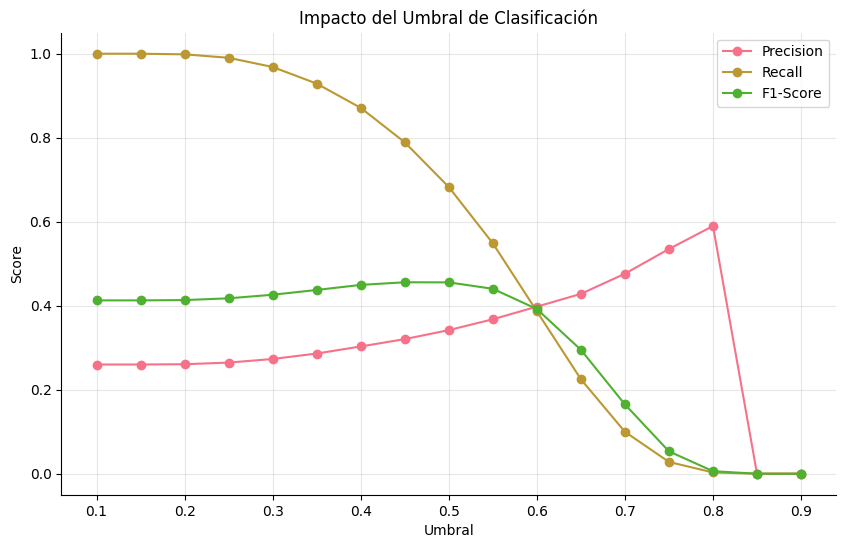

In [ ]:
# =====================================================
# 36. ANÁLISIS DE UMBRALES DE CLASIFICACIÓN
# =====================================================

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "Alertas generadas": y_pred_threshold.sum()
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")
plt.title("Impacto del Umbral de Clasificación")
plt.xlabel("Umbral")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 37 — Selección correcta del umbral usando Validation
En el paso anterior evaluamos con umbral 0.5. Pero en mantenimiento predictivo el umbral no siempre debe ser 0.5. Vamos a seleccionar el mejor umbral en validation y luego aplicarlo a test.

SELECCIÓN DE UMBRAL ÓPTIMO EN VALIDATION
✅ Mejor umbral según F1-Score en validation: 0.45


,Threshold,Precision,Recall,F1-Score,Alertas generadas
35,0.45,0.322150,0.754889,0.451585,17973
36,0.46,0.325924,0.732203,0.451066,17231
33,0.43,0.315178,0.792177,0.450943,19278
34,0.44,0.318284,0.773012,0.450909,18628
37,0.47,0.329578,0.709387,0.450060,16509
32,0.42,0.311612,0.809257,0.449962,19919
38,0.48,0.333460,0.685528,0.448673,15768
30,0.40,0.305193,0.843677,0.448239,21203
31,0.41,0.307670,0.824250,0.448083,20548
39,0.49,0.338284,0.662190,0.447805,15014


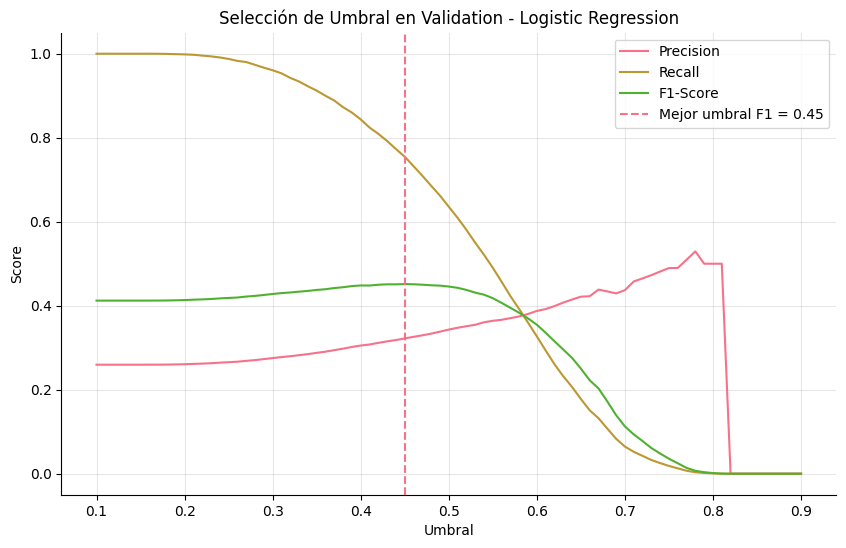

In [ ]:
# =====================================================
# 37. SELECCIÓN DE UMBRAL ÓPTIMO EN VALIDATION
# =====================================================

print("=" * 70)
print("SELECCIÓN DE UMBRAL ÓPTIMO EN VALIDATION")
print("=" * 70)

# Probabilidades del mejor modelo en validation
if hasattr(best_model, "predict_proba"):
    y_val_proba_best = best_model.predict_proba(X_val)[:, 1]
else:
    y_val_proba_best = best_model.decision_function(X_val)

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results_val = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba_best >= threshold).astype(int)

    threshold_results_val.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_val, y_val_pred_threshold, zero_division=0),
        "Alertas generadas": int(y_val_pred_threshold.sum())
    })

threshold_results_val = pd.DataFrame(threshold_results_val)

# Umbral que maximiza F1 en validation
best_threshold_f1 = threshold_results_val.loc[
    threshold_results_val["F1-Score"].idxmax(),
    "Threshold"
]

print(f"✅ Mejor umbral según F1-Score en validation: {best_threshold_f1:.2f}")

display(
    threshold_results_val
    .sort_values("F1-Score", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.plot(threshold_results_val["Threshold"], threshold_results_val["Precision"], label="Precision")
plt.plot(threshold_results_val["Threshold"], threshold_results_val["Recall"], label="Recall")
plt.plot(threshold_results_val["Threshold"], threshold_results_val["F1-Score"], label="F1-Score")
plt.axvline(best_threshold_f1, linestyle="--", label=f"Mejor umbral F1 = {best_threshold_f1:.2f}")
plt.title(f"Selección de Umbral en Validation - {best_model_name}")
plt.xlabel("Umbral")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 38 — Evaluación en Test con el umbral optimizado

EVALUACIÓN EN TEST CON UMBRAL OPTIMIZADO


,Modelo,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.45,0.510131,0.320479,0.789129,0.455835,0.652083,0.379831



Reporte de clasificación con umbral optimizado:
                  precision    recall  f1-score   support

No falla próxima       0.85      0.41      0.55     21730
   Falla próxima       0.32      0.79      0.46      7635

        accuracy                           0.51     29365
       macro avg       0.58      0.60      0.51     29365
    weighted avg       0.71      0.51      0.53     29365



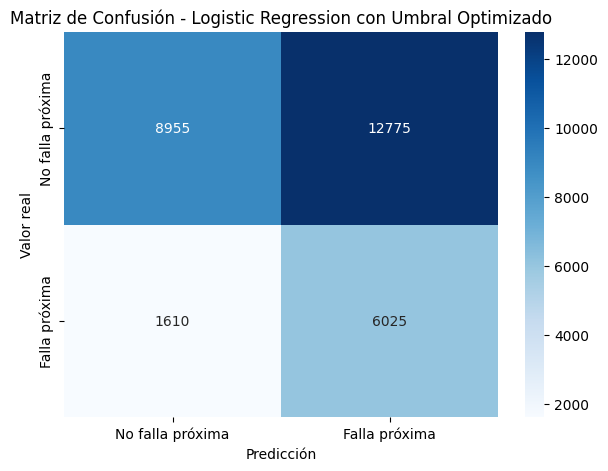

Verdaderos negativos: 8,955
Falsos positivos:    12,775
Falsos negativos:    1,610
Verdaderos positivos:6,025


In [ ]:
# =====================================================
# 38. EVALUACIÓN EN TEST CON UMBRAL OPTIMIZADO
# =====================================================

print("=" * 70)
print("EVALUACIÓN EN TEST CON UMBRAL OPTIMIZADO")
print("=" * 70)

# Probabilidades en test
if hasattr(best_model, "predict_proba"):
    y_test_proba_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_test_proba_best = best_model.decision_function(X_test)

# Predicción con umbral optimizado
y_test_pred_opt = (y_test_proba_best >= best_threshold_f1).astype(int)

optimized_test_metrics = {
    "Modelo": best_model_name,
    "Threshold": best_threshold_f1,
    "Accuracy": accuracy_score(y_test, y_test_pred_opt),
    "Precision": precision_score(y_test, y_test_pred_opt, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_opt, zero_division=0),
    "F1-Score": f1_score(y_test, y_test_pred_opt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_best),
    "PR-AUC": average_precision_score(y_test, y_test_proba_best)
}

display(pd.DataFrame([optimized_test_metrics]))

print("\nReporte de clasificación con umbral optimizado:")
print(classification_report(
    y_test,
    y_test_pred_opt,
    target_names=["No falla próxima", "Falla próxima"],
    zero_division=0
))

cm_opt = confusion_matrix(y_test, y_test_pred_opt)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No falla próxima", "Falla próxima"],
    yticklabels=["No falla próxima", "Falla próxima"]
)
plt.title(f"Matriz de Confusión - {best_model_name} con Umbral Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

tn, fp, fn, tp = cm_opt.ravel()

print(f"Verdaderos negativos: {tn:,}")
print(f"Falsos positivos:    {fp:,}")
print(f"Falsos negativos:    {fn:,}")
print(f"Verdaderos positivos:{tp:,}")

## Paso - Interpretación preliminar del resultado
### Interpretación preliminar de los modelos clásicos

Los modelos clásicos muestran que el problema de predicción de averías futuras no es trivial. El modelo con mejor desempeño inicial fue Logistic Regression, principalmente por su mayor capacidad de detección de fallas futuras, medida mediante recall.

Aunque modelos como Gradient Boosting alcanzaron mayor accuracy, su recall para la clase de falla fue demasiado bajo, lo cual los hace menos adecuados para un escenario de mantenimiento predictivo. En este tipo de aplicación, no detectar una falla futura puede ser más costoso que generar una falsa alarma, debido a los costos asociados a paradas no planificadas, indisponibilidad de equipos, daños secundarios y riesgos operacionales.

Por esta razón, la evaluación no debe centrarse únicamente en accuracy, sino en métricas como recall, F1-score y PR-AUC, que permiten analizar mejor el desempeño sobre la clase positiva.

## Paso 39 — Preparación de datos para la red neuronal MLP
Ahora vamos con la red neuronal. Primero transformamos los datos con el mismo tipo de preprocesamiento.

In [ ]:
# =====================================================
# 39. PREPARACIÓN DE DATOS PARA RED NEURONAL MLP
# =====================================================

print("=" * 70)
print("PREPARACIÓN DE DATOS PARA MLP")
print("=" * 70)

# Importar PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Verificar GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ GPU no disponible. Se usará CPU.")

# Preprocesador independiente para MLP
preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="drop"
)

# Ajustar solo con train
X_train_mlp = preprocessor_mlp.fit_transform(X_train)
X_val_mlp = preprocessor_mlp.transform(X_val)
X_test_mlp = preprocessor_mlp.transform(X_test)

# Convertir a tensores
X_train_tensor = torch.FloatTensor(X_train_mlp).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1).to(device)

X_val_tensor = torch.FloatTensor(X_val_mlp).to(device)
y_val_tensor = torch.FloatTensor(y_val.values).view(-1, 1).to(device)

X_test_tensor = torch.FloatTensor(X_test_mlp).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1).to(device)

# DataLoaders
BATCH_SIZE = 512

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Datos preparados para MLP")
print(f"Shape X_train_mlp: {X_train_mlp.shape}")
print(f"Shape X_val_mlp:   {X_val_mlp.shape}")
print(f"Shape X_test_mlp:  {X_test_mlp.shape}")

PREPARACIÓN DE DATOS PARA MLP
⚠️ GPU no disponible. Se usará CPU.
✅ Datos preparados para MLP
Shape X_train_mlp: (137851, 115)
Shape X_val_mlp:   (29548, 115)
Shape X_test_mlp:  (29365, 115)


## Paso 40 — Definición de la arquitectura MLP

In [ ]:
# =====================================================
# 40. DEFINICIÓN DE RED NEURONAL MLP
# =====================================================

class PredictiveMaintenanceMLP(nn.Module):
    """
    Red neuronal MLP para clasificación binaria de riesgo de falla futura.
    """

    def __init__(self, input_dim):
        super(PredictiveMaintenanceMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

INPUT_DIM = X_train_mlp.shape[1]

mlp_model = PredictiveMaintenanceMLP(INPUT_DIM).to(device)

print("=" * 70)
print("ARQUITECTURA MLP")
print("=" * 70)
print(mlp_model)

total_params = sum(p.numel() for p in mlp_model.parameters())
trainable_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)

print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

ARQUITECTURA MLP
PredictiveMaintenanceMLP(
  (network): Sequential(
    (0): Linear(in_features=115, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 25,665
Parámetros entrenables: 25,665


## Paso 41 — Configuración de entrenamiento del MLP

Vamos a usar `BCEWithLogitsLoss`, que es la función adecuada para clasificación binaria en PyTorch. Además, vamos a ponderar la clase positiva.

In [ ]:
# =====================================================
# 41. CONFIGURACIÓN DE ENTRENAMIENTO DEL MLP
# =====================================================

# Peso de clase positiva
pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-5)

EPOCHS = 50
PATIENCE = 8

print("=" * 70)
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("=" * 70)
print(f"Learning rate: 0.001")
print(f"Epochs máximas: {EPOCHS}")
print(f"Patience: {PATIENCE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"pos_weight: {pos_weight_value:.3f}")

CONFIGURACIÓN DE ENTRENAMIENTO
Learning rate: 0.001
Epochs máximas: 50
Patience: 8
Batch size: 512
pos_weight: 2.760


## Paso 42 — Funciones de entrenamiento y evaluación del MLP

In [ ]:
# =====================================================
# 42. FUNCIONES DE ENTRENAMIENTO Y VALIDACIÓN
# =====================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_mlp_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            total_loss += loss.item()

    return total_loss / len(loader)


def predict_mlp_proba(model, X_tensor, device):
    model.eval()

    probabilities = []

    with torch.no_grad():
        logits = model(X_tensor.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        probabilities.extend(probs)

    return np.array(probabilities)

## Paso 43 — Entrenamiento del MLP

In [ ]:
# =====================================================
# 43. ENTRENAMIENTO DEL MLP
# =====================================================

print("=" * 70)
print("ENTRENAMIENTO DEL MLP")
print("=" * 70)

history_mlp = {
    "train_loss": [],
    "val_loss": [],
    "val_f1": [],
    "val_recall": []
}

best_val_f1 = -np.inf
best_model_state = None
patience_counter = 0

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        mlp_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = evaluate_mlp_loss(
        mlp_model,
        val_loader,
        criterion,
        device
    )

    y_val_proba_mlp = predict_mlp_proba(mlp_model, X_val_tensor, device)
    y_val_pred_mlp = (y_val_proba_mlp >= 0.5).astype(int)

    val_f1 = f1_score(y_val, y_val_pred_mlp, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred_mlp, zero_division=0)

    history_mlp["train_loss"].append(train_loss)
    history_mlp["val_loss"].append(val_loss)
    history_mlp["val_f1"].append(val_f1)
    history_mlp["val_recall"].append(val_recall)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = mlp_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:03d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Val Recall: {val_recall:.4f}"
        )

    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping en epoch {epoch+1}")
        break

# Cargar mejor estado
mlp_model.load_state_dict(best_model_state)

print("\n✅ Entrenamiento del MLP finalizado")
print(f"Mejor F1 en validation: {best_val_f1:.4f}")

ENTRENAMIENTO DEL MLP
Epoch 001/50 | Train Loss: 0.9902 | Val Loss: 0.9653 | Val F1: 0.4439 | Val Recall: 0.6335
Epoch 005/50 | Train Loss: 0.9656 | Val Loss: 0.9623 | Val F1: 0.4529 | Val Recall: 0.6850
Epoch 010/50 | Train Loss: 0.9609 | Val Loss: 0.9608 | Val F1: 0.4481 | Val Recall: 0.6550

⚠️ Early stopping en epoch 13

✅ Entrenamiento del MLP finalizado
Mejor F1 en validation: 0.4529


## Paso 44 — Curvas de entrenamiento del MLP

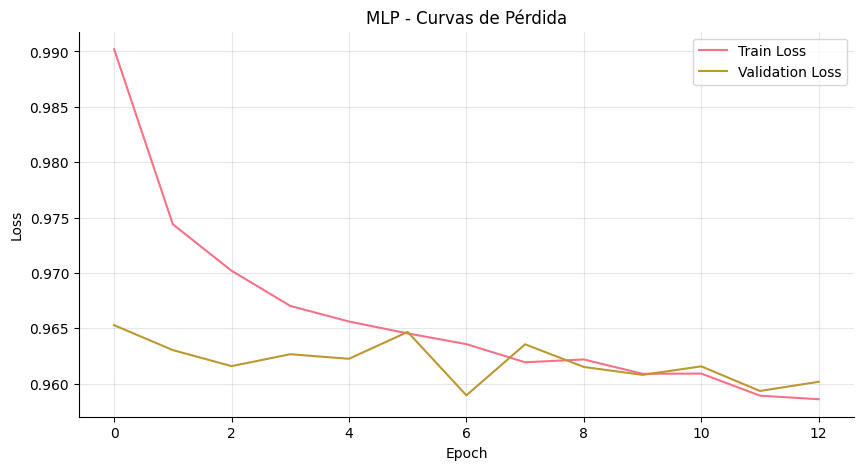

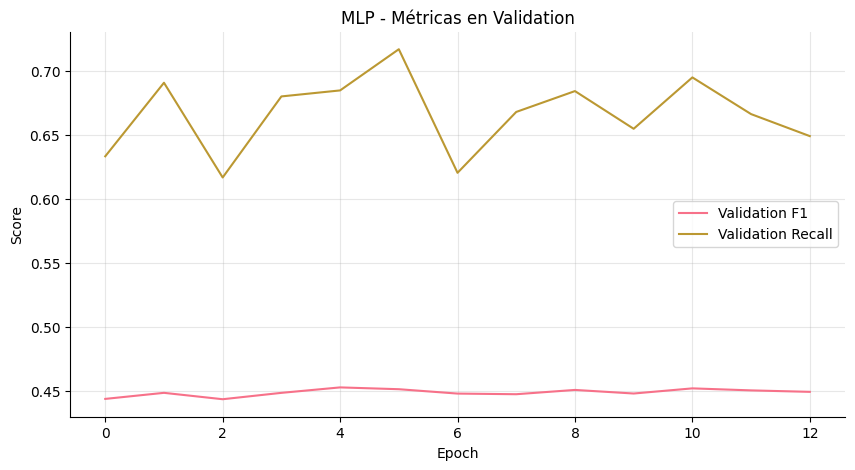

In [ ]:
# =====================================================
# 44. CURVAS DE ENTRENAMIENTO DEL MLP
# =====================================================

plt.figure(figsize=(10, 5))
plt.plot(history_mlp["train_loss"], label="Train Loss")
plt.plot(history_mlp["val_loss"], label="Validation Loss")
plt.title("MLP - Curvas de Pérdida")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_mlp["val_f1"], label="Validation F1")
plt.plot(history_mlp["val_recall"], label="Validation Recall")
plt.title("MLP - Métricas en Validation")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 45 — Evaluación del MLP en validation y test

In [ ]:
# =====================================================
# 45. EVALUACIÓN DEL MLP
# =====================================================

print("=" * 70)
print("EVALUACIÓN DEL MLP")
print("=" * 70)

# Probabilidades
y_val_proba_mlp = predict_mlp_proba(mlp_model, X_val_tensor, device)
y_test_proba_mlp = predict_mlp_proba(mlp_model, X_test_tensor, device)

# Predicciones con threshold 0.5
y_val_pred_mlp = (y_val_proba_mlp >= 0.5).astype(int)
y_test_pred_mlp = (y_test_proba_mlp >= 0.5).astype(int)

mlp_metrics_val = {
    "Modelo": "MLP Neural Network",
    "Accuracy": accuracy_score(y_val, y_val_pred_mlp),
    "Precision": precision_score(y_val, y_val_pred_mlp, zero_division=0),
    "Recall": recall_score(y_val, y_val_pred_mlp, zero_division=0),
    "F1-Score": f1_score(y_val, y_val_pred_mlp, zero_division=0),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_mlp),
    "PR-AUC": average_precision_score(y_val, y_val_proba_mlp)
}

mlp_metrics_test = {
    "Modelo": "MLP Neural Network",
    "Accuracy": accuracy_score(y_test, y_test_pred_mlp),
    "Precision": precision_score(y_test, y_test_pred_mlp, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_mlp, zero_division=0),
    "F1-Score": f1_score(y_test, y_test_pred_mlp, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_mlp),
    "PR-AUC": average_precision_score(y_test, y_test_proba_mlp)
}

print("Métricas MLP en validation:")
display(pd.DataFrame([mlp_metrics_val]))

print("Métricas MLP en test:")
display(pd.DataFrame([mlp_metrics_test]))

EVALUACIÓN DEL MLP
Métricas MLP en validation:


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,MLP Neural Network,0.586977,0.34359,0.649283,0.449377,0.647644,0.374627


Métricas MLP en test:


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,MLP Neural Network,0.567138,0.340918,0.712377,0.461147,0.659738,0.387121


## Paso 46 — Comparación final: modelos clásicos vs MLP

COMPARACIÓN FINAL EN VALIDATION


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
4,MLP Neural Network,0.586977,0.343590,0.649283,0.449377,0.647644,0.374627
0,Logistic Regression,0.589651,0.343189,0.635593,0.445714,0.640298,0.364057
1,XGBoost,0.604542,0.350108,0.611343,0.445236,0.651361,0.379110
2,Random Forest,0.629213,0.361092,0.556845,0.438096,0.649512,0.377520
3,Gradient Boosting,0.741302,0.524715,0.035984,0.067350,0.653981,0.382908


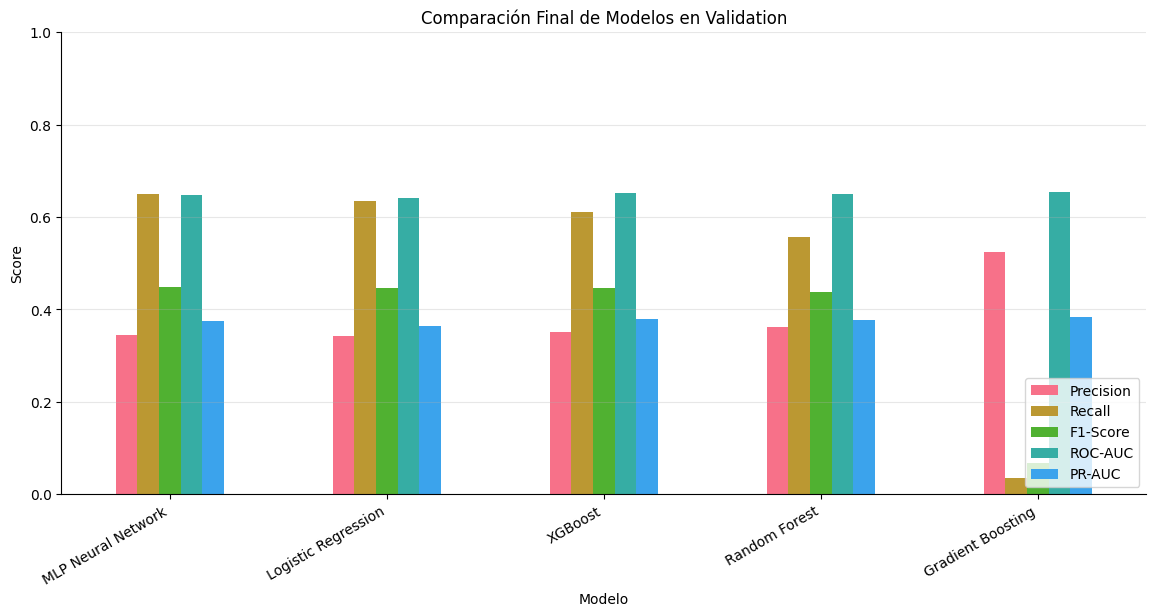

In [ ]:
# =====================================================
# 46. COMPARACIÓN FINAL DE MODELOS
# =====================================================

final_comparison = validation_results.copy()

# Agregar MLP a comparación de validation
final_comparison = pd.concat([
    final_comparison,
    pd.DataFrame([mlp_metrics_val])
], ignore_index=True)

final_comparison = final_comparison.sort_values("F1-Score", ascending=False)

print("=" * 70)
print("COMPARACIÓN FINAL EN VALIDATION")
print("=" * 70)

display(final_comparison)

metrics_to_plot = ["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]

final_comparison_plot = final_comparison.set_index("Modelo")[metrics_to_plot]

final_comparison_plot.plot(kind="bar", figsize=(14, 6))
plt.title("Comparación Final de Modelos en Validation")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show()

## Paso 47 — Selección final del mejor modelo incluyendo MLP

In [ ]:
# =====================================================
# 47. SELECCIÓN FINAL DEL MEJOR MODELO
# =====================================================

best_final_model_name = final_comparison.iloc[0]["Modelo"]

print(f"✅ Mejor modelo final según F1-Score en validation: {best_final_model_name}")

if best_final_model_name == "MLP Neural Network":
    print("El mejor modelo final es la red neuronal MLP.")
else:
    print(f"El mejor modelo final es: {best_final_model_name}")

✅ Mejor modelo final según F1-Score en validation: MLP Neural Network
El mejor modelo final es la red neuronal MLP.


## Paso 48 — Optimizar umbral del MLP en validation
Como el MLP fue el mejor modelo en validación, debemos optimizar su umbral también.

SELECCIÓN DE UMBRAL ÓPTIMO PARA MLP EN VALIDATION
✅ Mejor umbral MLP según F1-Score en validation: 0.41


,Threshold,Precision,Recall,F1-Score,Alertas generadas
31,0.41,0.319171,0.791395,0.454886,19018
32,0.42,0.321228,0.776141,0.454393,18532
35,0.45,0.328823,0.735072,0.454384,17146
33,0.43,0.323375,0.762060,0.454069,18075
34,0.44,0.325822,0.748370,0.453988,17617
36,0.46,0.331511,0.719557,0.453902,16648
30,0.40,0.315498,0.802608,0.452947,19512
29,0.39,0.313199,0.817340,0.452864,20016
37,0.47,0.333292,0.700913,0.451765,16130
28,0.38,0.310449,0.828944,0.451723,20480


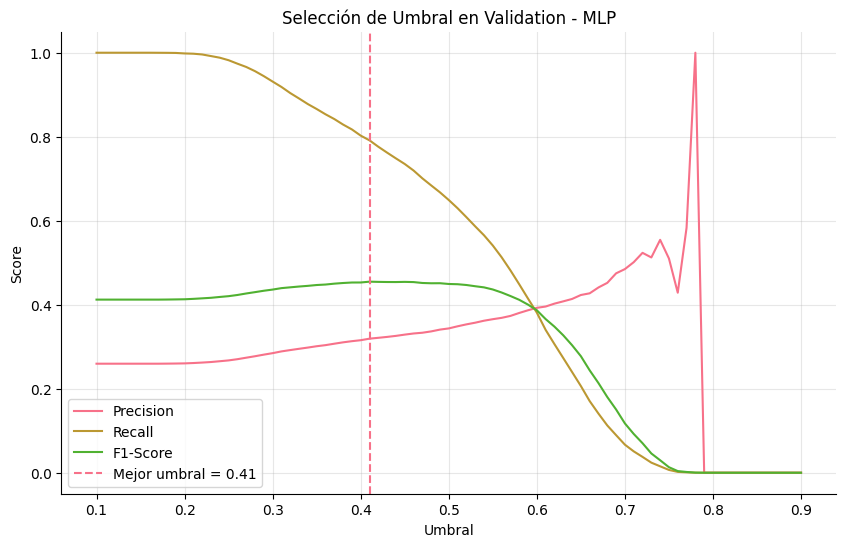

In [ ]:
# =====================================================
# 48. SELECCIÓN DE UMBRAL ÓPTIMO PARA EL MLP EN VALIDATION
# =====================================================

print("=" * 70)
print("SELECCIÓN DE UMBRAL ÓPTIMO PARA MLP EN VALIDATION")
print("=" * 70)

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results_mlp = []

for threshold in thresholds:
    y_val_pred_threshold_mlp = (y_val_proba_mlp >= threshold).astype(int)

    threshold_results_mlp.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred_threshold_mlp, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred_threshold_mlp, zero_division=0),
        "F1-Score": f1_score(y_val, y_val_pred_threshold_mlp, zero_division=0),
        "Alertas generadas": int(y_val_pred_threshold_mlp.sum())
    })

threshold_results_mlp = pd.DataFrame(threshold_results_mlp)

best_threshold_mlp = threshold_results_mlp.loc[
    threshold_results_mlp["F1-Score"].idxmax(),
    "Threshold"
]

print(f"✅ Mejor umbral MLP según F1-Score en validation: {best_threshold_mlp:.2f}")

display(
    threshold_results_mlp
    .sort_values("F1-Score", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.plot(threshold_results_mlp["Threshold"], threshold_results_mlp["Precision"], label="Precision")
plt.plot(threshold_results_mlp["Threshold"], threshold_results_mlp["Recall"], label="Recall")
plt.plot(threshold_results_mlp["Threshold"], threshold_results_mlp["F1-Score"], label="F1-Score")
plt.axvline(best_threshold_mlp, linestyle="--", label=f"Mejor umbral = {best_threshold_mlp:.2f}")
plt.title("Selección de Umbral en Validation - MLP")
plt.xlabel("Umbral")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 49 — Evaluación final del MLP con umbral optimizado

EVALUACIÓN FINAL DEL MLP CON UMBRAL OPTIMIZADO


,Modelo,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,MLP Neural Network,0.41,0.48064,0.31419,0.843353,0.457819,0.659738,0.387121



Reporte de clasificación con umbral optimizado:
                  precision    recall  f1-score   support

No falla próxima       0.87      0.35      0.50     21730
   Falla próxima       0.31      0.84      0.46      7635

        accuracy                           0.48     29365
       macro avg       0.59      0.60      0.48     29365
    weighted avg       0.72      0.48      0.49     29365



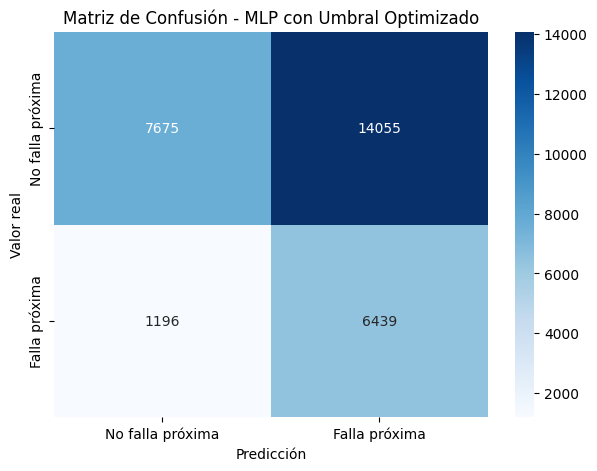

Verdaderos negativos: 7,675
Falsos positivos:    14,055
Falsos negativos:    1,196
Verdaderos positivos:6,439


In [ ]:
# =====================================================
# 49. EVALUACIÓN FINAL DEL MLP CON UMBRAL OPTIMIZADO
# =====================================================

print("=" * 70)
print("EVALUACIÓN FINAL DEL MLP CON UMBRAL OPTIMIZADO")
print("=" * 70)

y_test_pred_mlp_opt = (y_test_proba_mlp >= best_threshold_mlp).astype(int)

mlp_optimized_test_metrics = {
    "Modelo": "MLP Neural Network",
    "Threshold": best_threshold_mlp,
    "Accuracy": accuracy_score(y_test, y_test_pred_mlp_opt),
    "Precision": precision_score(y_test, y_test_pred_mlp_opt, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred_mlp_opt, zero_division=0),
    "F1-Score": f1_score(y_test, y_test_pred_mlp_opt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_mlp),
    "PR-AUC": average_precision_score(y_test, y_test_proba_mlp)
}

display(pd.DataFrame([mlp_optimized_test_metrics]))

print("\nReporte de clasificación con umbral optimizado:")
print(classification_report(
    y_test,
    y_test_pred_mlp_opt,
    target_names=["No falla próxima", "Falla próxima"],
    zero_division=0
))

cm_mlp_opt = confusion_matrix(y_test, y_test_pred_mlp_opt)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_mlp_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No falla próxima", "Falla próxima"],
    yticklabels=["No falla próxima", "Falla próxima"]
)
plt.title("Matriz de Confusión - MLP con Umbral Optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

tn, fp, fn, tp = cm_mlp_opt.ravel()

print(f"Verdaderos negativos: {tn:,}")
print(f"Falsos positivos:    {fp:,}")
print(f"Falsos negativos:    {fn:,}")
print(f"Verdaderos positivos:{tp:,}")

## Paso 50 — Curvas ROC y Precision-Recall del MLP

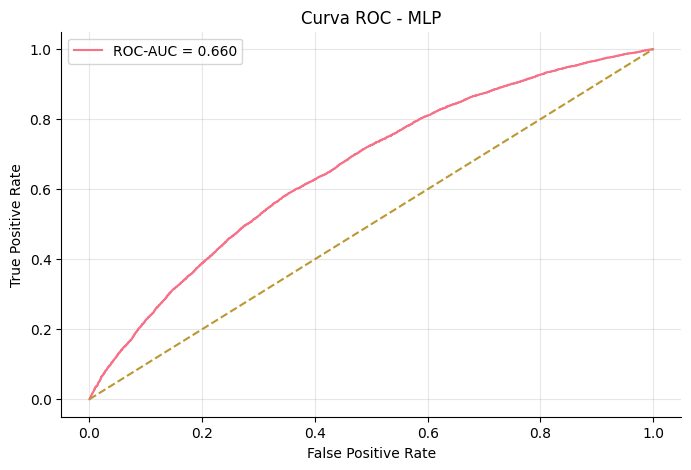

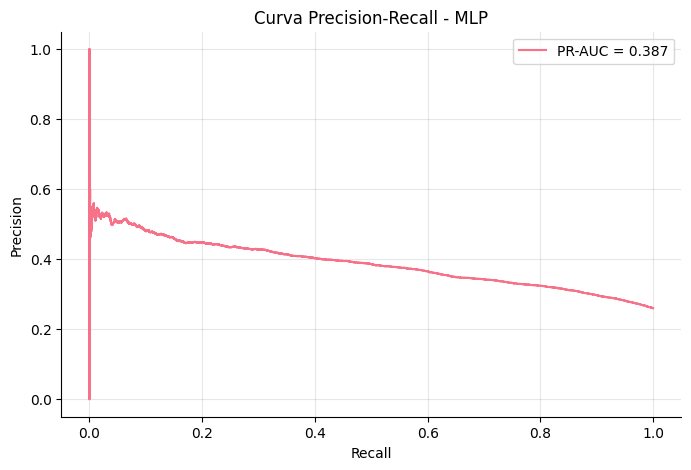

In [ ]:
# =====================================================
# 50. CURVAS ROC Y PRECISION-RECALL DEL MLP
# =====================================================

# Curva ROC
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_test_proba_mlp)

plt.figure(figsize=(8, 5))
plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"ROC-AUC = {mlp_optimized_test_metrics['ROC-AUC']:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - MLP")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Curva Precision-Recall
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_test_proba_mlp)

plt.figure(figsize=(8, 5))
plt.plot(
    recall_mlp,
    precision_mlp,
    label=f"PR-AUC = {mlp_optimized_test_metrics['PR-AUC']:.3f}"
)
plt.title("Curva Precision-Recall - MLP")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paso 51 — Tabla final de resultados del modelo seleccionado

In [ ]:
# =====================================================
# 51. TABLA FINAL DE RESULTADOS DEL MODELO SELECCIONADO
# =====================================================

final_model_results = pd.DataFrame([
    mlp_metrics_test,
    mlp_optimized_test_metrics
])

final_model_results["Configuración"] = [
    "MLP threshold 0.50",
    f"MLP threshold optimizado {best_threshold_mlp:.2f}"
]

final_model_results = final_model_results[
    [
        "Configuración",
        "Modelo",
        "Threshold" if "Threshold" in final_model_results.columns else "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

display(final_model_results)

,Configuración,Modelo,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,MLP threshold 0.50,MLP Neural Network,NaN,0.567138,0.340918,0.712377,0.461147,0.659738,0.387121
1,MLP threshold optimizado 0.41,MLP Neural Network,0.41,0.480640,0.314190,0.843353,0.457819,0.659738,0.387121


## Paso — Interpretación del MLP
### Selección del modelo final

Después de comparar modelos clásicos y una red neuronal MLP, el mejor desempeño en el conjunto de validación fue obtenido por el modelo **MLP Neural Network**. Aunque la diferencia frente a **Logistic Regression** y **XGBoost** no fue amplia, el MLP presentó el mejor F1-score en validación y un desempeño competitivo en test.

El modelo final fue evaluado con dos enfoques de umbral: el umbral estándar de 0.50 y un umbral optimizado a partir del conjunto de validación. Esta optimización es importante en mantenimiento predictivo porque permite ajustar el balance entre recall y precision según la estrategia de mantenimiento de la empresa.

En este caso, la métrica más relevante es el recall de la clase de falla futura, ya que un falso negativo representa una avería no anticipada. Sin embargo, también se analiza precision para controlar la cantidad de falsas alarmas generadas.

## Paso 52 — SHAP para explicar el MLP

INTERPRETABILIDAD DEL MLP CON SHAP
✅ SHAP calculado correctamente
Shape SHAP: (1000, 115)
Shape X explicado: (1000, 115)


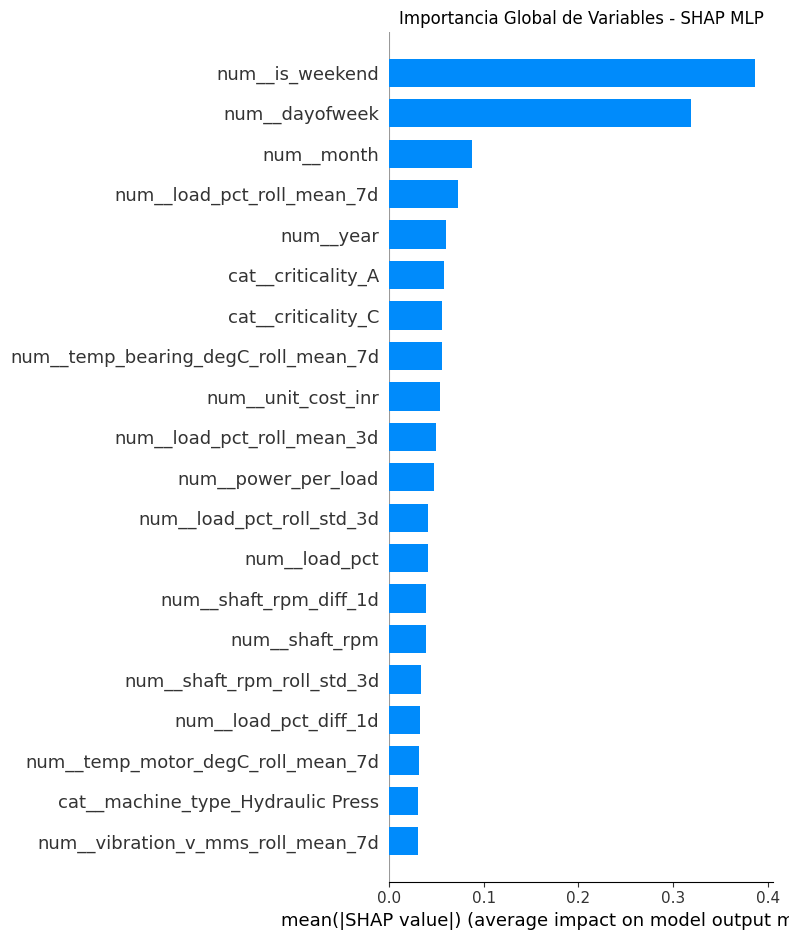

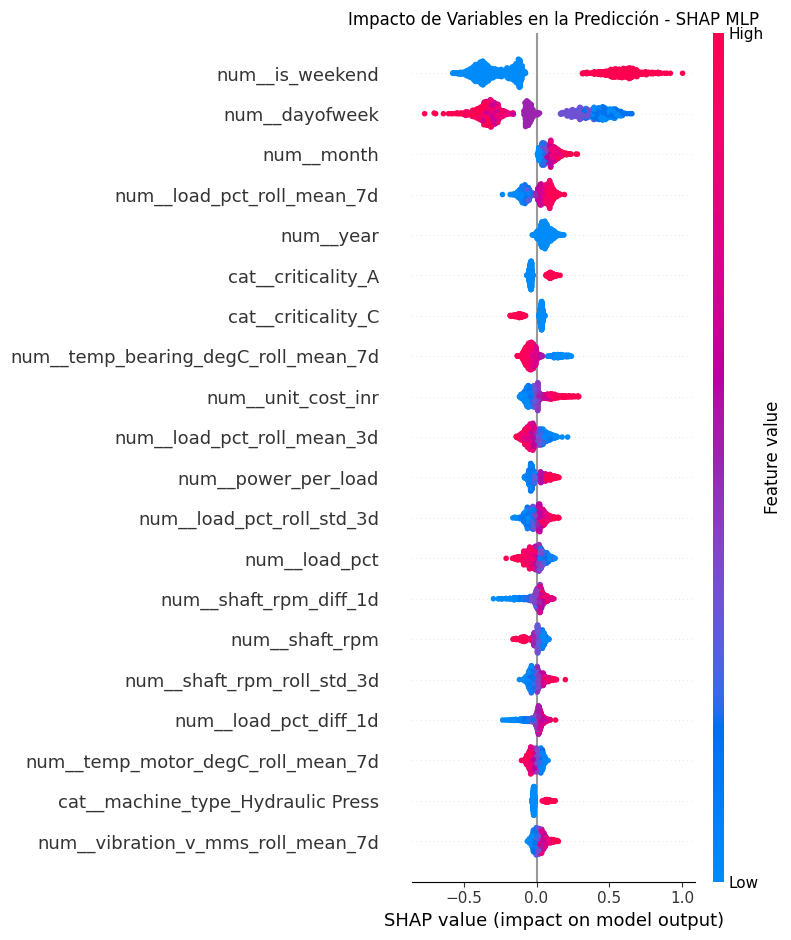

In [ ]:
# =====================================================
# 52. INTERPRETABILIDAD DEL MLP CON SHAP
# =====================================================

print("=" * 70)
print("INTERPRETABILIDAD DEL MLP CON SHAP")
print("=" * 70)

mlp_model.eval()

# Obtener nombres de variables transformadas
try:
    transformed_feature_names = preprocessor_mlp.get_feature_names_out()
except:
    ohe = preprocessor_mlp.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    transformed_feature_names = np.concatenate([numeric_features, cat_feature_names])

# Muestras para SHAP
np.random.seed(RANDOM_SEED)

background_size = min(500, X_train_mlp.shape[0])
explain_size = min(1000, X_test_mlp.shape[0])

background_idx = np.random.choice(X_train_mlp.shape[0], background_size, replace=False)
explain_idx = np.random.choice(X_test_mlp.shape[0], explain_size, replace=False)

background_tensor = torch.FloatTensor(X_train_mlp[background_idx]).to(device)
explain_tensor = torch.FloatTensor(X_test_mlp[explain_idx]).to(device)

try:
    explainer = shap.DeepExplainer(mlp_model, background_tensor)
    shap_values = explainer.shap_values(explain_tensor)

    # Manejo robusto de dimensiones
    if isinstance(shap_values, list):
        shap_array = shap_values[0]
    else:
        shap_array = shap_values

    shap_array = np.squeeze(shap_array)
    X_explain_np = X_test_mlp[explain_idx]

    print("✅ SHAP calculado correctamente")
    print(f"Shape SHAP: {shap_array.shape}")
    print(f"Shape X explicado: {X_explain_np.shape}")

    # Importancia global
    shap.summary_plot(
        shap_array,
        X_explain_np,
        feature_names=transformed_feature_names,
        plot_type="bar",
        max_display=20,
        show=False
    )
    plt.title("Importancia Global de Variables - SHAP MLP")
    plt.tight_layout()
    plt.show()

    # Summary plot detallado
    shap.summary_plot(
        shap_array,
        X_explain_np,
        feature_names=transformed_feature_names,
        max_display=20,
        show=False
    )
    plt.title("Impacto de Variables en la Predicción - SHAP MLP")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("⚠️ No fue posible calcular SHAP con DeepExplainer.")
    print("Error:", e)
    print("Se recomienda usar la importancia por permutación del siguiente paso como alternativa.")

## Paso 53 — Importancia agregada de variables

Top 20 variables más importantes agregadas:


,feature_original,mean_abs_shap
0,is_weekend,0.386104
1,dayofweek,0.318317
2,part_no,0.122472
3,criticality,0.122022
4,month,0.087365
5,asset_tag,0.085667
6,machine_type,0.084239
7,load_pct_roll_mean_7d,0.073299
8,part_family,0.067953
9,year,0.060426


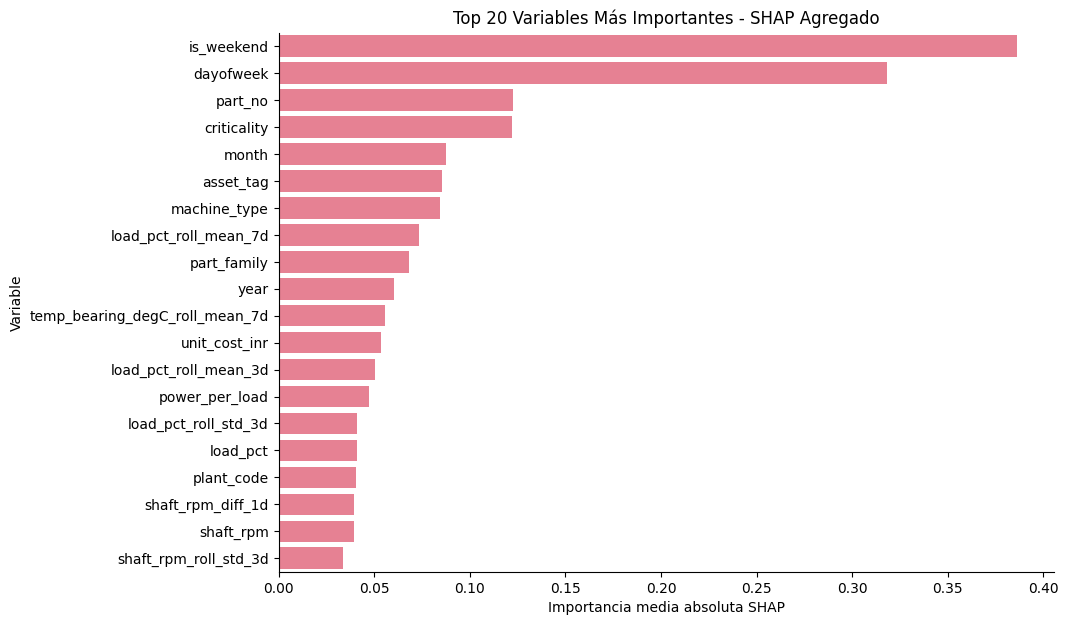

In [ ]:
# =====================================================
# 53. IMPORTANCIA AGREGADA DE VARIABLES SHAP
# =====================================================

def map_to_original_feature(feature_name, categorical_features):
    """
    Convierte nombres transformados por ColumnTransformer/OneHotEncoder
    a nombres originales de variables.
    """
    fname = str(feature_name)
    fname = fname.replace("num__", "").replace("cat__", "")

    for cat_col in categorical_features:
        if fname.startswith(cat_col + "_"):
            return cat_col

    return fname


try:
    shap_importance = pd.DataFrame({
        "feature_transformed": transformed_feature_names,
        "mean_abs_shap": np.abs(shap_array).mean(axis=0)
    })

    shap_importance["feature_original"] = shap_importance["feature_transformed"].apply(
        lambda x: map_to_original_feature(x, categorical_features)
    )

    shap_importance_agg = (
        shap_importance
        .groupby("feature_original")["mean_abs_shap"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    print("Top 20 variables más importantes agregadas:")
    display(shap_importance_agg.head(20))

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=shap_importance_agg.head(20),
        x="mean_abs_shap",
        y="feature_original"
    )
    plt.title("Top 20 Variables Más Importantes - SHAP Agregado")
    plt.xlabel("Importancia media absoluta SHAP")
    plt.ylabel("Variable")
    plt.show()

except Exception as e:
    print("⚠️ No se pudo generar la importancia agregada SHAP.")
    print("Error:", e)

## Paso 54 — Alternativa robusta: importancia por permutación del MLP
Esto netamente es una alternativa por si la anterior no funcionaba

IMPORTANCIA POR PERMUTACIÓN DEL MLP


,Variable,PR_AUC_base,PR_AUC_permutado,Importancia
17,dayofweek,0.398642,0.326454,0.072188
19,is_weekend,0.398642,0.359476,0.039165
6,unit_cost_inr,0.398642,0.384064,0.014577
4,part_family,0.398642,0.390985,0.007657
3,part_no,0.398642,0.391417,0.007225
5,criticality,0.398642,0.392100,0.006542
54,load_pct_roll_mean_7d,0.398642,0.392122,0.006520
63,power_consumption_kw_roll_std_3d,0.398642,0.394293,0.004349
24,power_per_load,0.398642,0.395235,0.003407
62,power_consumption_kw_roll_mean_3d,0.398642,0.395651,0.002991


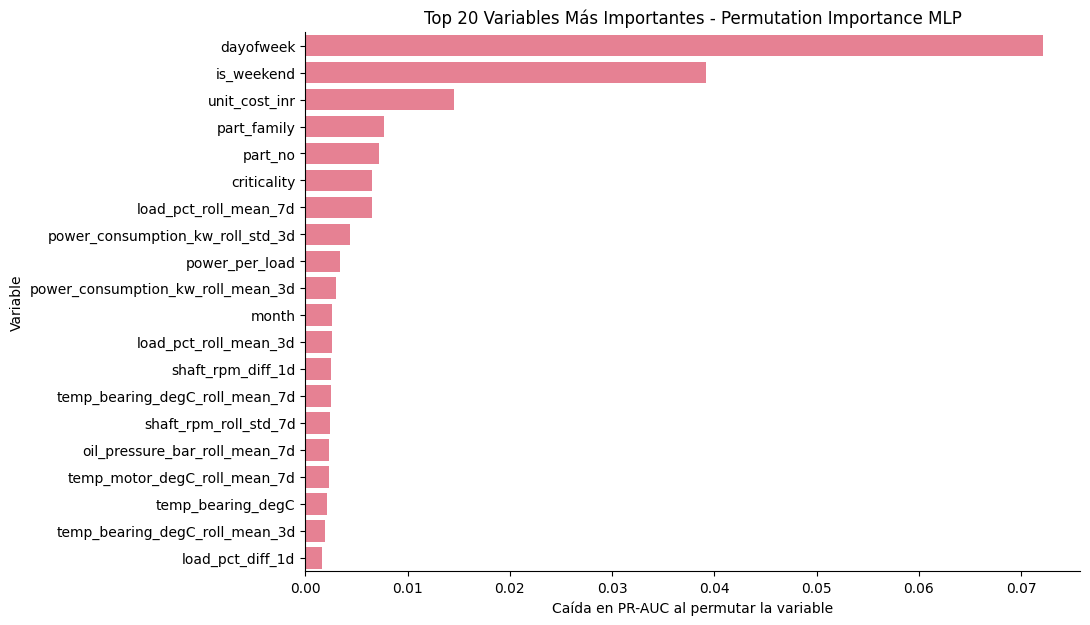

In [ ]:
# =====================================================
# 54. IMPORTANCIA POR PERMUTACIÓN DEL MLP
# =====================================================

print("=" * 70)
print("IMPORTANCIA POR PERMUTACIÓN DEL MLP")
print("=" * 70)

def predict_mlp_from_dataframe(X_df):
    """
    Genera probabilidades del MLP a partir de un DataFrame con columnas originales.
    """
    X_transformed = preprocessor_mlp.transform(X_df)
    X_tensor = torch.FloatTensor(X_transformed).to(device)

    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    return probs


# Muestra para reducir tiempo de cálculo
perm_sample_size = min(5000, len(X_test))
X_perm = X_test.sample(n=perm_sample_size, random_state=RANDOM_SEED)
y_perm = y_test.loc[X_perm.index]

base_proba = predict_mlp_from_dataframe(X_perm)
base_score = average_precision_score(y_perm, base_proba)

perm_results = []

for col in X_perm.columns:
    X_permuted = X_perm.copy()
    X_permuted[col] = np.random.permutation(X_permuted[col].values)

    perm_proba = predict_mlp_from_dataframe(X_permuted)
    perm_score = average_precision_score(y_perm, perm_proba)

    perm_results.append({
        "Variable": col,
        "PR_AUC_base": base_score,
        "PR_AUC_permutado": perm_score,
        "Importancia": base_score - perm_score
    })

perm_importance_df = (
    pd.DataFrame(perm_results)
    .sort_values("Importancia", ascending=False)
)

display(perm_importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=perm_importance_df.head(20),
    x="Importancia",
    y="Variable"
)
plt.title("Top 20 Variables Más Importantes - Permutation Importance MLP")
plt.xlabel("Caída en PR-AUC al permutar la variable")
plt.ylabel("Variable")
plt.show()

## Paso — Insights técnicos
### Interpretabilidad del modelo

La interpretabilidad del modelo se analizó mediante técnicas de importancia de variables. En el caso de la red neuronal MLP, se empleó SHAP sobre una muestra del conjunto de prueba y, adicionalmente, importancia por permutación para evaluar la sensibilidad del modelo ante la alteración de cada variable predictora.

Las variables más relevantes permiten identificar qué condiciones operativas y características del activo influyen más en la probabilidad estimada de falla futura. En términos de mantenimiento predictivo, estas variables pueden interpretarse como señales tempranas de degradación, esfuerzo operativo o condiciones anómalas de funcionamiento.

La interpretación del modelo es especialmente importante porque permite transformar la predicción en una recomendación accionable. No basta con conocer que un componente tiene alto riesgo de falla; también es necesario entender si la alerta está asociada a vibración elevada, temperatura anormal, presión de aceite, carga operativa, criticidad del componente o comportamiento reciente del activo.

## Paso 55 — Guardado del modelo final
Como el modelo final es MLP, guardaré lo siguiente:


*   arquitectura entrenada
*   preprocesador
*   umbral óptimo
*   columnas usadas
*   metadata del proyecto



In [ ]:
# =====================================================
# 55. GUARDADO DEL MODELO FINAL
# =====================================================

import os
import json
import joblib

MODEL_DIR = "/content/model_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

# Guardar modelo PyTorch
torch.save({
    "model_state_dict": mlp_model.state_dict(),
    "input_dim": INPUT_DIM,
    "threshold": float(best_threshold_mlp),
    "model_class": "PredictiveMaintenanceMLP",
    "random_seed": RANDOM_SEED
}, os.path.join(MODEL_DIR, "predictive_maintenance_mlp.pth"))

# Guardar preprocesador
joblib.dump(
    preprocessor_mlp,
    os.path.join(MODEL_DIR, "preprocessor_mlp.pkl")
)

# Guardar metadata
metadata = {
    "project_title": "Sistema de Alerta Temprana para Mantenimiento Predictivo",
    "target_column": TARGET_COLUMN,
    "prediction_horizon_days": HORIZON_DAYS,
    "selected_model": "MLP Neural Network",
    "optimized_threshold": float(best_threshold_mlp),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "excluded_columns": leakage_or_unused_cols,
    "test_metrics_threshold_05": mlp_metrics_test,
    "test_metrics_optimized_threshold": mlp_optimized_test_metrics
}

with open(os.path.join(MODEL_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Artefactos guardados correctamente en:")
print(MODEL_DIR)

print("\nArchivos generados:")
for file in os.listdir(MODEL_DIR):
    print("-", file)

✅ Artefactos guardados correctamente en:
/content/model_artifacts

Archivos generados:
- predictive_maintenance_mlp.pth
- model_metadata.json
- preprocessor_mlp.pkl


## Paso 56 — Comprimir artefactos para descarga

In [ ]:
# =====================================================
# 56. COMPRESIÓN DE ARTEFACTOS
# =====================================================

import shutil

zip_path = "/content/model_artifacts_predictive_maintenance.zip"

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=MODEL_DIR
)

print(f"✅ Archivo ZIP creado: {zip_path}")

✅ Archivo ZIP creado: /content/model_artifacts_predictive_maintenance.zip


# Conclusiones del proyecto
## Conclusiones

1. Se desarrolló un sistema de alerta temprana para mantenimiento predictivo capaz de estimar el riesgo de avería de un activo o componente industrial en los próximos tres días.

2. El problema fue formulado como una clasificación binaria, donde la variable objetivo `failure_next_3d` fue construida a partir de la ocurrencia futura de averías. Esta decisión permitió transformar el análisis desde una detección de falla actual hacia una predicción anticipada.

3. Para evitar fuga de información, se excluyeron variables como `wo_type` y `breakdown_flag` del conjunto de predictores. La primera puede revelar directamente el tipo de orden de trabajo, mientras que la segunda representa la falla actual.

4. Se compararon modelos clásicos de Machine Learning y una red neuronal MLP. La comparación incluyó Logistic Regression, Random Forest, Gradient Boosting, XGBoost y MLP Neural Network.

5. El modelo MLP obtuvo el mejor F1-score en validación y presentó un desempeño competitivo en el conjunto de prueba, destacándose por su capacidad para detectar una proporción relevante de fallas futuras.

6. La métrica más importante para este caso fue el recall de la clase positiva, debido a que en mantenimiento predictivo el costo de no detectar una falla puede ser mayor que el costo de generar una falsa alarma.

7. El análisis de interpretabilidad permitió identificar variables operativas y de condición que influyen en el riesgo de falla, facilitando la traducción del modelo hacia decisiones de mantenimiento accionables.

# Limitaciones

1. El dataset utilizado es sintético, por lo que los resultados deben interpretarse como una validación metodológica y no como un sistema directamente listo para operación industrial.

2. Aunque el dataset tiene un volumen considerable de registros, la calidad predictiva depende de la representatividad de las variables disponibles y de la correcta construcción de la variable objetivo.

3. La variable `failure_next_3d` fue construida mediante una ventana futura fija de tres días. Otros horizontes predictivos, como 1, 7 o 14 días, podrían producir resultados diferentes.

4. Algunas variables asociadas a repuestos o valores económicos fueron excluidas del modelo principal por posible riesgo de representar acciones posteriores al mantenimiento.

5. El modelo presenta un compromiso entre recall y precision. Detecta una proporción relevante de fallas futuras, pero también puede generar falsas alarmas.

6. Para una implementación real, sería necesario validar el modelo con datos históricos reales, definir costos de falsos positivos y falsos negativos, e integrarlo con sistemas de gestión de mantenimiento computarizado.

## Interpretación final del modelo seleccionado

El modelo final seleccionado fue una red neuronal MLP, debido a que obtuvo el mejor F1-score en el conjunto de validación frente a los modelos clásicos evaluados. Posteriormente, se optimizó el umbral de clasificación utilizando el conjunto de validación, obteniendo un umbral final de 0.41.

Con este umbral, el modelo alcanzó en el conjunto de prueba un recall de 0.843 para la clase de falla futura. Esto significa que el sistema es capaz de detectar aproximadamente el 84.3 % de los eventos de falla que ocurren en los próximos tres días.

Sin embargo, la precision obtenida fue de 0.314, lo cual indica que una proporción importante de las alertas generadas no termina en una falla real. En el contexto de mantenimiento predictivo, este comportamiento puede ser aceptable si el costo de una avería no anticipada es mayor que el costo de realizar inspecciones preventivas adicionales.

Por tanto, el modelo no debe interpretarse como un sistema automático de decisión final, sino como una herramienta de priorización de inspecciones. Su principal utilidad consiste en ordenar activos y componentes según su nivel de riesgo, permitiendo que el equipo de mantenimiento concentre sus recursos en los casos con mayor probabilidad de falla.

## Interpretabilidad del modelo

La interpretabilidad del modelo se realizó mediante SHAP, con el objetivo de identificar qué variables influyen más en la predicción de riesgo de falla futura.

Las variables más importantes fueron `is_weekend`, `dayofweek`, `part_no`, `criticality`, `month`, `asset_tag`, `machine_type`, `load_pct_roll_mean_7d`, `part_family` y `temp_bearing_degC_roll_mean_7d`.

Estos resultados muestran que el modelo utiliza tres tipos principales de información:

1. **Patrones temporales:** variables como `is_weekend`, `dayofweek` y `month` indican que la probabilidad de falla cambia según el calendario operativo.

2. **Características del activo y componente:** variables como `part_no`, `asset_tag`, `machine_type`, `part_family` y `criticality` muestran que ciertos activos, componentes y familias técnicas presentan mayor propensión histórica a fallar.

3. **Condiciones operativas recientes:** variables como `load_pct_roll_mean_7d`, `temp_bearing_degC_roll_mean_7d`, `shaft_rpm`, `shaft_rpm_diff_1d` y `power_per_load` reflejan que el modelo también aprende señales asociadas al comportamiento físico y operacional de la máquina.

Es importante aclarar que la importancia de una variable no implica causalidad directa. En especial, las variables temporales pueden estar capturando patrones de operación, programación de mantenimiento o características propias del dataset sintético.

## Resumen final

Este proyecto desarrolló un sistema de alerta temprana para mantenimiento predictivo de maquinaria industrial mediante Machine Learning explicable. El objetivo fue estimar si un activo o componente industrial tendría una avería en los próximos tres días, utilizando variables operativas, temporales y características técnicas del activo.

El dataset fue transformado para construir una variable objetivo predictiva denominada `failure_next_3d`. A diferencia de una detección de falla actual, esta variable permite anticipar eventos futuros y convertir el problema en una herramienta útil para la planificación del mantenimiento.

Se aplicó una metodología completa de ciencia de datos: limpieza del dataset, validación de calidad, ingeniería de características, construcción de variables temporales y operativas, división temporal de entrenamiento-validación-prueba, comparación de modelos clásicos y entrenamiento de una red neuronal MLP.

Los modelos evaluados fueron Logistic Regression, Random Forest, Gradient Boosting, XGBoost y MLP Neural Network. El modelo final seleccionado fue la red neuronal MLP, que obtuvo el mejor desempeño en validación según F1-score. Posteriormente, se optimizó el umbral de clasificación, obteniendo un umbral final de 0.41.

En el conjunto de prueba, el modelo final alcanzó un recall de 0.843 para la clase de falla futura, lo que indica que detecta aproximadamente el 84.3 % de las fallas que ocurren en los próximos tres días. Aunque la precision fue de 0.314, este comportamiento es coherente con un sistema de alerta temprana, donde se prioriza reducir fallas no detectadas.

Finalmente, se aplicó SHAP para interpretar el modelo. Las variables más importantes estuvieron asociadas a patrones temporales, características del activo y condiciones operativas recientes, especialmente día de la semana, fin de semana, componente, criticidad, tipo de máquina, carga promedio reciente y temperatura promedio del rodamiento.